# **Установка библиотек, импорты и конфигурация**

In [ ]:
!pip install pymorphy3
!pip install rouge
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 46.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import math
import json
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.model_selection import train_test_split
import pymorphy3
import os
import gc
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, f1_score
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from collections import defaultdict
from rouge import Rouge
from xgboost import XGBClassifier
import pickle
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
savePath = '/content/drive/MyDrive/Data/parts_data_project'
if not os.path.exists(savePath):
    os.makedirs(savePath)
    time.sleep(3)

RECOMPUTE_FEATURES = False
RECOMPUTE_PARAMS = False
EPOCHS = 500

In [ ]:
positive_words = [
      'верно', 'отлично', 'хорошо', 'правильно', 'да', 'супер', 'умничка',
      'молодец', 'попал во все ключи', 'попала во все ключи', 'в ключи попал', 'в ключи попала',
      'ура'
  ]
negative_words = [
    'ошибка', 'неверно', 'нет', 'внимательнее', 'лишнее', 'лишнего', 'не попал',
    'мало', 'не объяснил', 'не объяснила', 'не засчитано', 'почему пропустил', 'почему пропустила',
    'внимательно ознакомься', 'учим теорию', 'не забывай', 'не до конца',
    'некорректно'
]
scaler_lr = StandardScaler()

# **Загрузка данных**

**Описание датасета.** Датасет `querc.json` содержит ответы учеников на вопросы по обществознанию. Каждая запись включает вопрос, тип задания, максимальный балл за задание, эталонный ответ, теорию для задания, заметки для учителя, ответ ученика, ответ учителя и оценку учителя. Задача — автоматически предсказать, является ли ответ ученика верным (бинарная классификация).

Датасет содержит два типа заданий:
- **Обычные задания** — короткие ответы, оцениваются как верно/неверно.
- **Задания с планом** — развёрнутые ответы с иерархической структурой, требующие более сложного анализа.

In [ ]:
data = pd.read_json('/content/drive/MyDrive/Data/querc.json', encoding='utf-8-sig')
data

,Question,Type,Maxbal,SampleAnswer,Theory,Sumary,StudentAnswer,TeacherMark,Score
0,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\r\r1. Инт...,,,Отличительные признаки революции:\n1)насилие\n...,"{""ops"":[{""insert"":""Отличительные признаки рево...",2
1,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\r\r1. Инт...,,,Отличия : \n1) Революция характеризуется как с...,"{""ops"":[{""insert"":""Отличия : \n1) Революция ха...",1
2,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\r\r1. Инт...,,,три отличия революции от других социальных дви...,,0
3,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\r\r1. Инт...,,,1) интенсивный процесс \n2) носит насильственн...,"{""ops"":[{""attributes"":{""color"":""#e60000""},""ins...",2
4,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\r\r1. Инт...,,,1)интенсивность процесса \n2)насильственный ха...,"{""ops"":[{""attributes"":{""color"":""#e60000""},""ins...",2
...,...,...,...,...,...,...,...,...,...
19325,В государстве Х президент возглавляет исполнит...,22,4,1. Форма правления: президентская республика\n...,,,президентская республика\n2,,0
19326,В тексте упомянуты ключевые понятия социально-...,18,2,1. Основные признаки формы правления:\n — ...,,,1 признаки\n- степень участия народа в управле...,"{""ops"":[{""insert"":""1 признаки""},{""attributes"":...",0
19327,В тексте упомянуты ключевые понятия социально-...,18,2,1. Основные признаки формы правления:\n — ...,,,1) - определение способа формирования государс...,"{""ops"":[{""insert"":""1) ""},{""attributes"":{""color...",1
19328,В тексте упомянуты ключевые понятия социально-...,18,2,1. Основные признаки формы правления:\n — ...,,,1. 1) Характеризует структуру и полномочия выс...,"{""ops"":[{""insert"":""1. ""},{""attributes"":{""color...",2


In [ ]:
data['SampleAnswer'] = data["SampleAnswer"].str.replace('\r', '\n ').str.replace('\uFEFF', '', regex=False).str.replace('—', '-', regex=False).str.replace('–', '-', regex=False).str.strip()
data['StudentAnswer'] = data["StudentAnswer"].str.replace('\r', '\n ').str.replace('\uFEFF', '', regex=False).str.replace('—', '-', regex=False).str.replace('–', '-', regex=False).str.strip()
data['TeacherMark'] = data["TeacherMark"].str.replace('\r', '\n ').str.replace('\uFEFF', '', regex=False).str.replace('—', '-', regex=False).str.replace('–', '-', regex=False).str.strip()
data

,Question,Type,Maxbal,SampleAnswer,Theory,Sumary,StudentAnswer,TeacherMark,Score
0,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\n \n 1. И...,,,Отличительные признаки революции:\n1)насилие\n...,"{""ops"":[{""insert"":""Отличительные признаки рево...",2
1,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\n \n 1. И...,,,Отличия : \n1) Революция характеризуется как с...,"{""ops"":[{""insert"":""Отличия : \n1) Революция ха...",1
2,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\n \n 1. И...,,,три отличия революции от других социальных дви...,,0
3,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\n \n 1. И...,,,1) интенсивный процесс \n2) носит насильственн...,"{""ops"":[{""attributes"":{""color"":""#e60000""},""ins...",2
4,"Что, по мысли автора, выделяет революцию из др...",17,2,Отличия революции от других течений:\n \n 1. И...,,,1)интенсивность процесса \n2)насильственный ха...,"{""ops"":[{""attributes"":{""color"":""#e60000""},""ins...",2
...,...,...,...,...,...,...,...,...,...
19325,В государстве Х президент возглавляет исполнит...,22,4,1. Форма правления: президентская республика\n...,,,президентская республика\n2,,0
19326,В тексте упомянуты ключевые понятия социально-...,18,2,1. Основные признаки формы правления:\n - ...,,,1 признаки\n- степень участия народа в управле...,"{""ops"":[{""insert"":""1 признаки""},{""attributes"":...",0
19327,В тексте упомянуты ключевые понятия социально-...,18,2,1. Основные признаки формы правления:\n - ...,,,1) - определение способа формирования государс...,"{""ops"":[{""insert"":""1) ""},{""attributes"":{""color...",1
19328,В тексте упомянуты ключевые понятия социально-...,18,2,1. Основные признаки формы правления:\n - ...,,,1. 1) Характеризует структуру и полномочия выс...,"{""ops"":[{""insert"":""1. ""},{""attributes"":{""color...",2


In [ ]:
data_questions = pd.DataFrame(data["Question"])
data_questions['Type'] = data['Type']
data_questions.drop_duplicates(inplace=True)
data_questions.reset_index(drop=True, inplace=True)
data_questions #Уникальные вопросы с типом задания

,Question,Type
0,"Что, по мысли автора, выделяет революцию из др...",17
1,В тексте упомянуты ключевые понятия социально-...,18
2,На графике изображено изменение ситуации на по...,21
3,Конституция Российской Федерации провозглашает...,23
4,"Автор обращает внимание на то, что весь ролево...",19
...,...,...
510,"Авторы отмечают, что ни одно государство не мо...",20
511,"Используя обществоведческие знания, составьте ...",24
512,Проиллюстрируйте тремя примерами из российской...,19
513,"Приведите три аргумента, подтверждающих сужден...",20


# **Парсинг ответов**

Ответы учителей содержат как текст ученика, так и пометки учителя, разделённые специальными маркерами. На этом этапе:
- Извлекаем ответы учеников
- Парсим ответы на пункты и подпункты, задания с планом оставляем как есть
- Определяем оценку учителя по ключевым словам (`верно`, `неверно` и т.д.)
- Строим отдельные датафреймы для обычных заданий и заданий с планом

Работаем с пометками учителя, так как ученики не всегда делают правильное оформление, из-за чего парсинг по пунктам может быть затруднительным. Учитель всегда доставляет это оформление

## Вспомогательные функции

In [ ]:
def split_text(answ_text, markers):
  res = []
  answ_text_split = []
  min_ind = math.inf
  first_marker = ''

  for marker in markers:
    matches = list(re.finditer(marker, answ_text)) #Возвращает все вхождения для данного шаблона
    for j in range(len(matches)):
      if(matches[j].start() < min_ind): #Ищем, какой нумерацией пользовался ученик
        min_ind = matches[j].start()
        first_marker = marker

  if(min_ind == math.inf): #Если никакой, например переносы, или это чисто 1 строка(определения, пункты через запятые)
    marker = r'\s*\n'
    match_marker = re.search(marker, answ_text)
    if(match_marker):
      answ_text_split = re.split(marker, answ_text)
    else:
      answ_text_split.append(answ_text)
  else:
    answ_text_split = re.split(first_marker, answ_text[min_ind:])

  for s in answ_text_split:
    res.append(s)
  return res

In [ ]:
def double_split(answ_text):
  res = []
  markers_lvl1 = [r'(?:^|\n)\d+\.\d+', r'(?:^|\n)\d+\.', r'(?:^|\n)\d+\)', r'(?:^|\n)№\d+' ,r'(?:^|\n)\d+\b', r'(?:^|\n)[а-яА-Я][\.\)]', r'(?:^|\n)\-'] #Возможные шаблоны нумерации пунктов(без \s* так как бывают ответы, где пункты и подпункты одинаковые, поэтому ищем только там, где пункт прилеплен к левому краю)
  parts = split_text(answ_text, markers_lvl1) #Делим на пункты

  markers_lvl2 = [r'(?:^|\n)\s*\d+\.\d+', r'(?:^|\n)\s*\d+\.', r'(?:^|\n)\s*\d+\)', r'(?:^|\n)\s*\d+\b', r'(?:^|\n)\s*[а-яА-Я][\.\)]', r'(?:^|\n)\s*\-'] #Для подпунктов
  i = 0
  for part in parts:
    flag = False
    sub_parts = split_text(part, markers_lvl2) #Делим на подпункты каждый пункт
    j = 0
    for sub_part in sub_parts:
      clean_text = re.sub(r'\s+', ' ', sub_part).strip().lower()
      if(clean_text != '' and not clean_text.endswith(':')):
        clean_text = clean_text.strip('.')
        res.append({'item_id': f"{i+1}.{j+1}", 'Answer': clean_text}) #Если в первом пункте 3 подпункта, будет 1.1 1.2 1.3
        j += 1
        flag = True
    if(flag):
      i += 1
  return res

In [ ]:
def search_grade(teacher_mark):
  tm_clean = re.sub(r'(\w)\1{2,}', r'\1', teacher_mark.lower().strip()) #Учитель может писать "дааааааа", нужно заменить на "да"

  killers = ['ставится ноль', '0 баллов', 'не засчитано', 'не по заданию']
  if any(k in tm_clean for k in killers):
      return 0

  if(re.search(r'(?<!\w)\+(?!\w)', tm_clean)): #Отдельно стоит +
    return 1
  if(re.search(r'(?<!\w)\-(?!\w)', tm_clean)): #Отдельно стоит -
    return 0

  digits = re.search(r'(\d+)\/\s*', tm_clean) #Учитель может писать "за это задание 1/2", вытаскиваем 1
  if(digits):
    return int(digits.group(1))

  if any(word in tm_clean for word in positive_words):
      return 1
  if any(word in tm_clean for word in negative_words):
      return 0

  return 0

In [ ]:
def get_grades(split_parts, teacher_mark):
  res = []
  marks = list(re.finditer(r'\[teacher_start\](.*?)\[teacher_end\]', teacher_mark)) #При обработке данных пометки учителя обозначаем такими скобками

  filtered_marks = [m.group(1) for m in marks]

  if(len(split_parts) == len(filtered_marks)): #Если количество пунктов и количество пометок совпадают, то по очереди добавляем в результат эти оценки
    for i in range(len(filtered_marks)):
      res.append(search_grade(filtered_marks[i]))
  else:
    if(len(filtered_marks) == 1): #Если оценка одна, значит она распространяется на все пункты
      grade = search_grade(filtered_marks[0])
      res.extend([grade] * len(split_parts))
    else:
      for i in range(len(filtered_marks)):
        grade = search_grade(filtered_marks[i])
        for j in range(len(split_parts)):
          if(re.search(rf'{i+1}\.\d', split_parts[j]['item_id'])): #Если количество пометок и пунктов не совпадают, пытаемся сопоставить i-ю пометку с пунктом по item_id (например, пометка 1 → пункт 1.1, 1.2 и т.д.)
            res.append(grade)
  if len(res) < len(split_parts):
    res.extend([0] * (len(split_parts) - len(res))) #Если все случаи не покрыты, остальные пункты получают 0
  return res

## Парсинг

In [ ]:
for i in range(len(data)):
  teacher_mark = data.loc[i, 'TeacherMark']
  current_answer = '' #Ответ ученика
  current_feedback = '' #Ответ преподавателя
  isLastFeedback = False #Нужно, если в датасете пометки преподавателя идут несколько раз подряд
  isDraftReached = False #Если ученик писал черновик(для себя)
  if(teacher_mark != ""):
    mark_obj = json.loads(teacher_mark)['ops'] #Это массив из объектов, в каждом есть свойство insert
    for item in mark_obj:
      val = item['insert']
      is_empty_val = re.sub(r'\s+', '', val) == ""

      if('ЧЕРНОВИК' in val):
        val = val[:val.find('ЧЕРНОВИК')] #Берём всё до черновика, мало ли есть ещё какой-то текст
        isDraftReached = True
      if(isDraftReached and val.strip() == ""): #Если текста нет, то прерываемся для данного ответа
        break

      if('attributes' in item): #Атрибуты могут быть: color, bold, italic, list:bullet(маркировка), strike
        if('color' in item['attributes']): #Если текст преподавателя
          if(is_empty_val): #Иногда в val просто \n
            if(isLastFeedback): #Если в прошлый раз была пометка учителя, и в этот раз тоже, то считаем это как один текст
              current_feedback = current_feedback.rstrip().rstrip('[teacher_end]')
              current_feedback += " " + val + '[teacher_end]'
            else:
              current_answer += val
            #Тут isLastFeedback не меняем, потому что val не несёт какой-то смысловой нагрузки
            continue
          has_eval_sign = val.strip() in ['+', '-'] and ' ' not in val
          has_marker_word = any(word in val.lower() for word in positive_words + negative_words)
          if(has_marker_word): #Если есть хотя бы одно триггер слово, это ответ преподавателя
            current_feedback += f" [teacher_start]{val}[teacher_end] " #isLastFeedback точно false, поэтому слева и справа добавляем обозначения
            isLastFeedback = True
            continue
          decor_match = re.search(r'\s*(?:\d+(?:\.\d+|[\.\)\b])|[а-яА-Я][\.\)]|(?:\n|^)\s*\-\s*\w*)', val) #Преподаватель дополняет пропущенную пунктуацию. Если так, то это уйдёт в ответ ученика
          is_short_label = re.fullmatch(r'\s*[А-Яа-я]{1,12}\s*:\s*', val or "") is not None #Преподаватель может дописывать за учеников слова, которые обязательно нужны для задания(например - "Пример:")
          if((decor_match and len(val.strip()) <= 10) or (not has_eval_sign and is_short_label)):
              current_answer += val
              isLastFeedback = False
          else:
              if(isLastFeedback): #Если в прошлый раз был ответ учителя, и в этот раз тоже, то добавляем текст в один блок
                current_feedback = current_feedback.rstrip().rstrip('[teacher_end]')
                current_feedback += " " + val + '[teacher_end]'
              else:
                current_feedback += f" [teacher_start]{val}[teacher_end] " #Иначе создаём новый блок
              isLastFeedback = True
        else:
          current_answer += val
          isLastFeedback = False
      else:
        current_answer += val
        if(re.sub(r'\s+', '', val) != ""): #Если была какая-то смысловая нагрузка
          isLastFeedback = False
      if isDraftReached: #Если перед черновиком был текст, то мы его добавили, а теперь должны остановиться
        break
    data.loc[i, 'StudentAnswer'] = current_answer
    data.loc[i, 'TeacherMark'] = current_feedback
data

KeyboardInterrupt: 

## Построение датасета

In [ ]:
res_students_X = []
res_students_Y = []
res_students_plan_X = []
res_students_plan_Y = []
studentAnswers = pd.DataFrame(data.loc[:, ['Question', 'StudentAnswer', 'Score', 'Maxbal']])
studentAnswers.rename(columns={'StudentAnswer': 'Answer'}, inplace=True)

for i in range(len(studentAnswers)): #len(studentAnswers)
  teacher_mark = data.loc[i, 'TeacherMark']
  if(teacher_mark == ""): #Если пометки нет, пропускаем
    continue
  answ_text = studentAnswers.loc[i, 'Answer'].strip()
  question_id = data_questions.loc[data_questions['Question'] == studentAnswers.loc[i, 'Question']].index[0]
  score = studentAnswers.loc[i, 'Score']
  maxbal = studentAnswers.loc[i, 'Maxbal']
  if(re.search(r'\bплан\b', studentAnswers.loc[i, 'Question'].lower()) is not None): #Если это задание про планы, то добавляем в отдельный список
    clean_text = answ_text.strip().lower()
    res_students_plan_X.append({'question_id': question_id, 'item_id': 1, 'Answer': clean_text})
    grade = score
    res_students_plan_Y.append(grade)
  else: #Обычные задания
    split_parts = double_split(answ_text) #Делим на пункты и подпункты
    valid_parts = [part for part in split_parts if(len(part['Answer']) > 1)] #Оставляем только нормальные ответы
    for part in valid_parts:
      res_students_X.append({'question_id': question_id, 'item_id': part['item_id'], 'Answer': part['Answer']})
    if(score == maxbal): #Если оценка максимальная, значит всё правильно
      grades = [1] * len(valid_parts)
    else:
      grades = get_grades(valid_parts, teacher_mark) #Ищем оценки и выставляем
    res_students_Y.extend(grades)
print(len(res_students_X))
print(len(res_students_Y))
print(len(res_students_plan_X))
print(len(res_students_plan_Y))

In [ ]:
res_samples_X = []
res_samples_Y = []
res_samples_plan_X = []
res_samples_plan_Y = []
#Берём не пустые правильный ответы, удаляем дубликаты и заново формируем индексы
unique_sampleAnswers = pd.DataFrame(data.loc[data['SampleAnswer'].str.strip() != "", ['Question', 'SampleAnswer']])
unique_sampleAnswers.rename(columns={'SampleAnswer': 'Answer'}, inplace=True)
unique_sampleAnswers.drop_duplicates(inplace=True)
unique_sampleAnswers.reset_index(drop=True, inplace=True)

for i in range(len(unique_sampleAnswers)):
  answ_text = unique_sampleAnswers.loc[i, 'Answer'].strip()
  mask = data_questions['Question'] == unique_sampleAnswers.loc[i, 'Question']
  question_id = data_questions.loc[mask].index[0]
  if(re.search(r'\bплан\b', unique_sampleAnswers.loc[i, 'Question'].lower()) is not None): #Если это задание про планы, то добавляем в отдельный список
    clean_text = answ_text.strip().lower()
    res_samples_plan_X.append({'question_id': question_id, 'item_id': 1, 'Answer': clean_text})
    res_samples_plan_Y.append(data.loc[data['Type'] == data_questions.loc[mask, 'Type'].iloc[0], 'Maxbal'].iloc[0]) #Так как ответы правильные, то берём максимальную оценку
  else: #Обычные задания
    split_parts = double_split(answ_text) #Делим на пункты и подпункты
    valid_parts = [part for part in split_parts if(len(part['Answer']) > 1)] #Оставляем только нормальные ответы
    for part in valid_parts:
      res_samples_X.append({'question_id': question_id, 'item_id': part['item_id'], 'Answer': part['Answer']})
      res_samples_Y.append(1) #Так как ответы правильные, то оценка за пункт - 1
print(len(res_samples_X))
print(len(res_samples_Y))
print(len(res_samples_plan_X))
print(len(res_samples_plan_Y))

In [ ]:
df = pd.DataFrame(res_students_X, columns=['question_id', 'item_id', 'Answer'])
df['Grade'] = res_students_Y
df.drop_duplicates(subset=['question_id', 'item_id', 'Answer', 'Grade'], inplace=True)
df.reset_index(drop=True, inplace=True)
df['Grade'] = df['Grade'].apply(lambda x: 1 if x >= 1 else 0) #Если какая-то оценка неправильно поставилась
df

In [ ]:
df_gold = pd.DataFrame(res_samples_X, columns=['question_id', 'item_id', 'Answer'])
df_gold['Grade'] = res_samples_Y
df_gold

In [ ]:
df_plan = pd.DataFrame(res_students_plan_X, columns=['question_id', 'item_id', 'Answer'])
df_plan['Grade'] = res_students_plan_Y
df_plan.drop_duplicates(subset=['question_id', 'item_id', 'Answer', 'Grade'], inplace=True)
df_plan.reset_index(drop=True, inplace=True)
df_plan['Grade'] = df_plan['Grade'].apply(lambda x: 1 if x >= 3 else 0)
#В датасете очень мало примеров с оценками 1 и 2, поэтому, для упрощения, делаем бинарную классификацию -
#всё, что меньше 3 - 0, остальное - 1
df_plan

In [ ]:
df_plan_gold = pd.DataFrame(res_samples_plan_X, columns=['question_id', 'item_id', 'Answer'])
df_plan_gold['Grade'] = res_samples_plan_Y
df_plan_gold['Grade'] = 1 #Тут будут все 4, но так как у нас классификация 0 или 1, то превращаем оценки в 1
df_plan_gold

# **Анализ датасета**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_tmp, title in zip(axes, [df, df_plan], ['Обычные задания', 'Задания с планом']):
  cnt = df_tmp['Grade'].value_counts().sort_index()
  ax.bar(['Неверно (0)', 'Верно (1)'], cnt.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
  ax.set_title(f'Распределение классов\n({title})', fontsize=13)
  ax.set_ylabel('Количество примеров')
  for j, v in enumerate(cnt.values):
    ax.text(j, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout();
plt.show()

In [ ]:
type_counts = data_questions['Type'].value_counts()
plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(type_counts)), type_counts.values, color='#1abc9c', edgecolor='black')
plt.xticks(range(len(type_counts)), [f'Тип {t}' for t in type_counts.index])
plt.title('Количество уникальных вопросов по типам заданий', fontsize=13)
plt.ylabel('Количество вопросов')
for bar, v in zip(bars, type_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout();
plt.show()

print()

print(f"Всего ответов учеников (обычные): {len(df)}")
print(f"Всего ответов учеников (планы):   {len(df_plan)}")
print(f"Уникальных вопросов:              {len(data_questions)}")

# **Векторизация данных**

Для каждого ответа ученика вычисляем набор признаков, отражающих его схожесть с эталонным ответом:
- **Семантическое сходство** — с помощью нейросетевой модели `paraphrase-multilingual-mpnet-base-v2` (SentenceTransformer). Модель является нейронной сетью на основе BERT и позволяет получить векторное представление текста, учитывающее контекст и смысл
- **ROUGE-1 и ROUGE-2** — метрики перекрытия n-грамм между ответом и эталоном.
- **Лексическое перекрытие** — доля совпадающих лемм
- **Длина ответа** и соотношение длин
- **Дополнительные и пропущенные факты** — что есть в ответе, чего нет в эталоне, и наоборот

## Вспомогательные функции и загрузка моделей

In [ ]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
rouge = Rouge()

In [ ]:
morph = pymorphy3.MorphAnalyzer() #Для лемматизация
def get_lemmas(text):
    lemmas = []
    for s in text.split(' '): #Делим текст по пробелам
        if(len(s) < 3):
            continue
        word = morph.parse(s)[0].normal_form #Берём нормальную форму для слова
        lemmas.append(word)
    return set(lemmas)

## Обычные задания

In [ ]:
#Делим на 5 частей, так как ОЗУ в Google Collab не хватает для векторизации целого DataFrame
df1 = df[:5000]
df2 = df[5000:10000]
df3 = df[10000:15000]
df4 = df[15000:20000]
df5 = df[20000:]
df_parts = [df1, df2, df3, df4, df5]

In [ ]:
if(RECOMPUTE_FEATURES or not os.path.exists(f'{savePath}/gold_vectors_dict.pkl')):
  gold_vectors_dict = defaultdict(list)
  #Словарь списков - по id задания выдаётся правильный ответ, который векторизуется и добавляется в список
  #Список, так как порядок пунктов из ответа ученика и порядок пунктов из эталонного ответа могут не совпадать

  for i in range(len(df_gold)):
    key = df_gold.loc[i, 'question_id']
    vector = model.encode(df_gold.loc[i, 'Answer'])
    gold_vectors_dict[key].append((vector, df_gold.loc[i, 'Answer']))
    print(f'{i+1} из {len(df_gold)} выполнено')

  with open(f'{savePath}/gold_vectors_dict.pkl', 'wb') as f:
      pickle.dump(gold_vectors_dict, f)
  print('Векторы сохранены')
else:
  with open(f'{savePath}/gold_vectors_dict.pkl', 'rb') as f:
      gold_vectors_dict = pickle.load(f)
  print('Векторы загружены из файла')

In [ ]:
if(RECOMPUTE_FEATURES or not os.path.exists(f'{savePath}/X_0.npy')):
  for idx, part in enumerate(df_parts): #Проходимся по нашим ответам учеников, разделёненными на части
    X_part = []
    Y_part = []
    Q_part = []
    X_lstm_part = []

    part = part.reset_index(drop=True) #Обнуляем индексацию
    for i in range(len(part)):
      q_id = part.loc[i, 'question_id']

      res_list = gold_vectors_dict.get(q_id) #Получаем эталонные ответы для данного задания
      if(res_list is not None):
        student_text = part.loc[i, 'Answer']
        v_student = model.encode(student_text) #Векторизируем ответ ученика

        candidates = []
        for v_gold, text_gold in res_list:
          sim = util.cos_sim(v_gold, v_student).item() #Считаем косинусную близость для каждого эталонного ответа
          candidates.append((sim, text_gold))

        candidates_best = sorted(candidates, key=lambda x: x[0], reverse=True) #Сортируем в убывающем порядке по близости

        best_sim = candidates_best[0][0] #Лучшая близость
        second_best_sim = candidates_best[1][0] if len(candidates_best) > 1 else 0 #Вторая лучшая близость, если есть
        sim_gap = best_sim - second_best_sim #Разница между двумя близостями
        best_gold_text = candidates_best[0][1] #Лучший эталонный ответ

        v_gold_best = [v for v, t in res_list if t == best_gold_text][0]
        pair_vector = np.concatenate([v_gold_best, v_student])

        set_s = get_lemmas(student_text) #Лемматизируем ответ ученика
        set_g = get_lemmas(best_gold_text) #Лемматизируем эталонный ответ
        try:
          rouge_score = rouge.get_scores(student_text, best_gold_text)[0]
          overlap_r1 = rouge_score['rouge-1']['f'] #Доля совпадающих слов между ответом студента и эталоном
          overlap_r2 = rouge_score['rouge-2']['f'] #Доля совпадающих пар соседних слов между ответом студента и эталоном
        except ValueError:
          overlap_r1 = 0
          overlap_r2 = 0

        missing = len(set_g - set_s) #Сколько слов упустил ученик
        extra = len(set_s - set_g) #Сколько лишних слов он написал
        overlap = len(set_s & set_g) #Сколько слов совпало с эталонным ответов

        len_ratio = len(student_text.split()) / len(best_gold_text.split()) if len(best_gold_text.split()) > 0 else 0
        #Соотношение длин ответов

        is_negative = int(((re.search(r'\bне\b|\bнет\b', best_gold_text) is not None) != (re.search(r'\bне\b|\bнет\b', student_text) is not None)))
        #Когда ученик написал утверждение вместо отрицания или наоборот

        q_type = data_questions.iloc[q_id].loc['Type'] #Тип вопроса из DataFrame уникальных вопросов

        row = np.hstack([
            [q_type],
            [best_sim],
            [second_best_sim],
            [sim_gap],
            [len(student_text.split())],
            [len_ratio],
            [overlap_r1],
            [overlap_r2],
            [overlap],
            [extra],
            [missing],
            [is_negative]
        ])
        X_part.append(row)
        Y_part.append(part.loc[i, 'Grade'])
        Q_part.append(q_id)
        X_lstm_part.append(pair_vector)

    #После цикла по одной части сохраняем в файл
    np.save(f'{savePath}/X_{idx}.npy', np.array(X_part))
    np.save(f'{savePath}/Y_{idx}.npy', np.array(Y_part))
    np.save(f'{savePath}/Q_{idx}.npy', np.array(Q_part))
    np.save(f'{savePath}/X_lstm_{idx}.npy', np.array(X_lstm_part))
    print(f'{idx+1} часть выполнена ')

    del X_part, Y_part, part, Q_part, X_lstm_part #Освобождаем память
    gc.collect()

In [ ]:
X = []
Y = []
Q = []
X_lstm = []
X_parts = []
Y_parts = []
Q_parts = []
X_lstm_parts = []
for idx in range(len(df_parts)): #Проходимся по разделённым частям и загружаем наши массивы с признаками
  X_parts.append(np.load(f'{savePath}/X_{idx}.npy'))
  Y_parts.append(np.load(f'{savePath}/Y_{idx}.npy'))
  Q_parts.append(np.load(f'{savePath}/Q_{idx}.npy'))
  X_lstm_parts.append(np.load(f'{savePath}/X_lstm_{idx}.npy'))

#Объединяем в один массив
X = np.concatenate(X_parts, axis=0)
Y = np.concatenate(Y_parts, axis=0)
Q = np.concatenate(Q_parts, axis=0)
X_lstm = np.concatenate(X_lstm_parts, axis=0)
del X_parts, Y_parts, Q_parts, X_lstm_parts #Освобождаем память
gc.collect()
print(len(X))
print(len(Y))

## Задания с планом

In [ ]:
if(RECOMPUTE_FEATURES or not os.path.exists(f'{savePath}/gold_vectors_dict_plan.pkl')):
  gold_vectors_dict_plan = {} #По id задания выдаётся правильный ответ, который векторизуется и добавляется в словарь

  for i in range(len(df_plan_gold)):
    key = df_plan_gold.loc[i, 'question_id']
    vector = model.encode(df_plan_gold.loc[i, 'Answer'])
    gold_vectors_dict_plan[key] = (vector, df_plan_gold.loc[i, 'Answer'])
    print(f'{i+1} из {len(df_plan_gold)} выполнено')
    gold_vectors_dict = defaultdict(list)

  with open(f'{savePath}/gold_vectors_dict_plan.pkl', 'wb') as f:
      pickle.dump(gold_vectors_dict_plan, f)
  print('Векторы сохранены')
else:
  with open(f'{savePath}/gold_vectors_dict_plan.pkl', 'rb') as f:
      gold_vectors_dict_plan = pickle.load(f)
  print('Векторы загружены из файла')

In [ ]:
def get_plan_structure(plan_text): #Метод, который считает количество пунктов и подпунктов
  markers_lvl1 = [r'(?:^|\n)\d+\.\d+', r'(?:^|\n)\d+\.', r'(?:^|\n)\d+\)', r'(?:^|\n)\d+\b', r'(?:^|\n)[а-яА-Я][\.\)]', r'(?:^|\n)\-']
  parts = split_text(plan_text, markers_lvl1) #Делим на пункты

  markers_lvl2 = [r'(?:^|\n)\s*\d+\.\d+', r'(?:^|\n)\s*\d+\.', r'(?:^|\n)\s*\d+\)', r'(?:^|\n)\s*\d+\b', r'(?:^|\n)\s*[а-яА-Я][\.\)]', r'(?:^|\n)\s*\-']
  points = 0
  sub_points = 0
  for part in parts:
    flag = False
    sub_parts = split_text(part, markers_lvl2) #Делим получившиеся пункты на подпункты
    for sub_part in sub_parts:
      clean_text = re.sub(r'\s+', ' ', sub_part).strip().lower()
      if(clean_text != '' and not clean_text.endswith(':')): #В пункте действительно есть подпункты
        sub_points += 1
        flag = True
    if(flag):
      points += 1
  return (points, sub_points)

In [ ]:
if(RECOMPUTE_FEATURES or not os.path.exists(f'{savePath}/X_plan_1.npy')):
  X_plan_part = []
  Y_plan_part = []
  Q_plan_part = []
  X_lstm_part = []
  for i in range(len(df_plan)):
    q_id = df_plan.loc[i, 'question_id']

    gold = gold_vectors_dict_plan.get(q_id) #Получаем эталонный ответ
    if(gold is not None):
      student_text = df_plan.loc[i, 'Answer']
      v_student = model.encode(student_text) #Векторизируем ответ ученика

      v_gold, text_gold = gold #Извлекаем вектор и текст эталонного ответа

      sim = util.cos_sim(v_gold, v_student).item() #Считаем косинусное сходство

      pair_vector = np.concatenate([v_gold, v_student])

      set_s = get_lemmas(student_text) #Лемматизация ответа ученика
      set_g = get_lemmas(text_gold) #Лемматизация ответа ученика
      overlap = len(set_s & set_g) / len(set_g) if len(set_g) > 0 else 0 #Доля лемм эталонного ответа найденных в ответе ученика
      missing = len(set_g - set_s) #Сколько слов упустил ученик

      len_ratio = len(student_text) / len(text_gold) if len(text_gold) > 0 else 0 #Соотношение длин ответов

      points, sub_points = get_plan_structure(student_text) #Количество пунктов и подпунктов ответа ученика
      gold_points, gold_sub_points = get_plan_structure(text_gold) #Количество пунктов и подпунктов эталонного ответа

      pts_ratio = points / gold_points if gold_points > 0 else 0 #Соотношение количества пунктов
      subs_ratio = sub_points / gold_sub_points if gold_sub_points > 0 else 0 #Соотношение количества подпунктов

      row = np.hstack([
          [sim],
          [len(student_text)],
          [len_ratio],
          [overlap],
          [missing],
          [points],
          [sub_points],
          [pts_ratio],
          [subs_ratio]
      ])
      X_plan_part.append(row)
      Y_plan_part.append(df_plan.loc[i, 'Grade'])
      Q_plan_part.append(q_id)
      X_lstm_part.append(pair_vector)

  #Сохраняем признаки
  np.save(f'{savePath}/X_plan_1.npy', np.array(X_plan_part))
  np.save(f'{savePath}/Y_plan_1.npy', np.array(Y_plan_part))
  np.save(f'{savePath}/Q_plan_1.npy', np.array(Q_plan_part))
  np.save(f'{savePath}/X_lstm_plan_1.npy', np.array(X_lstm_part))

  del X_plan_part, Y_plan_part, Q_plan_part, X_lstm_part #Освобождаем память
  gc.collect()
  print('Признаки сохранены')

In [ ]:
X_plan = []
Y_plan = []
Q_plan = []
X_lstm_plan = []
X_plan_parts = []
Y_plan_parts = []
Q_plan_parts = []
X_lstm_plan_parts = []

#Загружаем признаки
X_plan_parts.append(np.load(f'{savePath}/X_plan_1.npy'))
Y_plan_parts.append(np.load(f'{savePath}/Y_plan_1.npy'))
Q_plan_parts.append(np.load(f'{savePath}/Q_plan_1.npy'))
X_lstm_plan_parts.append(np.load(f'{savePath}/X_lstm_plan_1.npy'))

#Объединяем в один массив
X_plan = np.concatenate(X_plan_parts, axis=0)
Y_plan = np.concatenate(Y_plan_parts, axis=0)
Q_plan = np.concatenate(Q_plan_parts, axis=0)
X_lstm_plan = np.concatenate(X_lstm_plan_parts, axis=0)
del X_plan_parts, Y_plan_parts, Q_plan_parts, X_lstm_plan_parts #Освобождаем память
gc.collect()
print(len(X_plan))
print(len(Y_plan))

# **Обучение моделей и НС**

На этом этапе обучаем три классификатора на извлечённых признаках. Разделение на train/test происходит по уникальным вопросам, чтобы модель не переобучалась на конкретные формулировки

Для каждой модели:
1. Подбираем гиперпараметры через `RandomizedSearchCV` с метрикой `f1_macro`
2. Обучаем финальную модель с найденными параметрами
3. Подбираем оптимальный порог классификации по F1-macro на тестовой выборке

## Обычные задания

In [ ]:
unique_questions_id = np.unique(Q) #Берём уникальные вопросы
train_q, test_q = train_test_split(unique_questions_id, test_size=0.2, random_state=42) #Делим датасет по вопросам

X_train = X[np.isin(Q, train_q)]
Y_train = Y[np.isin(Q, train_q)]
X_test = X[np.isin(Q, test_q)]
Y_test = Y[np.isin(Q, test_q)]

X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled  = scaler_lr.transform(X_test)

X_lstm_train = X_lstm[np.isin(Q, train_q)]
X_lstm_test  = X_lstm[np.isin(Q, test_q)]

X_lstm_train_t = torch.tensor(X_lstm_train, dtype=torch.float32).reshape(-1, 2, 768)
Y_train_t      = torch.tensor(Y_train, dtype=torch.float32)
X_lstm_test_t  = torch.tensor(X_lstm_test,  dtype=torch.float32).reshape(-1, 2, 768)

def find_threshold(y_pred_proba):
  thresholds = np.arange(0.30, 0.70, 0.01)
  best_thresh = 0.5
  best_f1 = 0

  for thresh in thresholds:
      y_pred_thresh = (y_pred_proba > thresh).astype(int)
      f1 = f1_score(Y_test, y_pred_thresh, average='macro')
      if f1 > best_f1:
          best_f1 = f1
          best_thresh = thresh
  return (best_thresh, best_f1)

### XGBoost

In [ ]:
if(RECOMPUTE_PARAMS or not os.path.exists(f'{savePath}/best_params_xgb.txt')):
  #Подбор гиперпараметров
  model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

  param_grid_xgb = {
      'n_estimators': [100, 200, 300],
      'max_depth': [3, 4, 5],
      'learning_rate': [0.01, 0.05, 0.1],
      'subsample': [0.7, 0.8],
      'colsample_bytree': [0.7, 0.8],
      'min_child_weight': [3, 5, 10],
      'gamma': [0, 0.1, 0.3],
      'scale_pos_weight': [0.6, 0.8, 1.0]
  }

  rand_search_xgb = RandomizedSearchCV(estimator=model_xgb, param_distributions=param_grid_xgb, n_iter=100, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
  rand_search_xgb.fit(X_train, Y_train)
  param_grid_xgb_best = rand_search_xgb.best_params_

  with open(f'{savePath}/best_params_xgb.txt', 'w') as f: #Сохраняем в файл
      for param, value in param_grid_xgb_best.items():
          f.write(f"{param}: {value}\n")
  print('Параметры XGBoost сохранены')
else:
  param_grid_xgb_best = {}
  with open(f'{savePath}/best_params_xgb.txt', 'r') as f: #Читаем из файла
      for line in f:
          param, value = line.strip().split(': ', 1)
          if value.isdecimal():
              param_grid_xgb_best[param] = int(value)
          elif value.replace('.', '', 1).isdecimal():
              param_grid_xgb_best[param] = float(value)
          else:
              param_grid_xgb_best[param] = value
  print('Параметры XGBoost загружены')
print(param_grid_xgb_best)

Параметры XGBoost загружены
{'subsample': 0.7, 'scale_pos_weight': 0.6, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [ ]:
model_xgb = XGBClassifier( #Основная модель для обучения, с подобранными параметрами
    **param_grid_xgb_best,
    eval_metric='logloss',
    random_state=42,
)

model_xgb.fit(X_train, Y_train) #Обучаем модель

y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1] #Предсказыаем оценки

#Ищем оптимальный порог по f1_score
best_thresh_xgb, best_f1_xgb = find_threshold(y_pred_proba_xgb)

print(f'Лучший порог: {best_thresh_xgb:.2f}, F1-macro на test: {best_f1_xgb:.4f}')

Лучший порог: 0.51, F1-macro на test: 0.6004


### LogisticRegression

In [ ]:
if RECOMPUTE_PARAMS or not os.path.exists(f'{savePath}/best_params_lr.txt'):
    model_lr = LogisticRegression(random_state=42)

    param_grid_lr = [
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'class_weight': [None, 'balanced'],
            'max_iter': [2000]
        },
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'penalty': ['elasticnet'],
            'solver': ['saga'],
            'l1_ratio': [0.2, 0.5, 0.7],
            'class_weight': [None, 'balanced'],
            'max_iter': [2000]
        }
    ]

    rand_search_lr = RandomizedSearchCV(estimator=model_lr, param_distributions=param_grid_lr, n_iter=30, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
    rand_search_lr.fit(X_train_scaled, Y_train)
    param_grid_lr_best = rand_search_lr.best_params_

    with open(f'{savePath}/best_params_lr.txt', 'w') as f:
        for param, value in param_grid_lr_best.items():
            f.write(f"{param}: {value}\n")
    print('Параметры Logistic Regression сохранены')
else:
    param_grid_lr_best = {}
    with open(f'{savePath}/best_params_lr.txt', 'r') as f:
        for line in f:
            param, value = line.strip().split(': ', 1)
            if value.isdecimal():
                param_grid_lr_best[param] = int(value)
            elif value.replace('.', '', 1).isdecimal():
                param_grid_lr_best[param] = float(value)
            elif value == 'None':
                param_grid_lr_best[param] = None
            else:
                param_grid_lr_best[param] = value
    print('Параметры Logistic Regression загружены')
print(param_grid_lr_best)

Параметры Logistic Regression загружены
{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 2000, 'class_weight': 'balanced', 'C': 0.001}


In [ ]:
model_lr = LogisticRegression(**param_grid_lr_best, random_state=42)
model_lr.fit(X_train_scaled, Y_train)  # Обучаем модель на масштабированных данных

y_pred_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]  # Предсказываем оценки

# Ищем оптимальный порог по f1_score
best_thresh_lr, best_f1_lr = find_threshold(y_pred_proba_lr)

print(f'Лучший порог: {best_thresh_lr:.2f}, F1-macro на test: {best_f1_lr:.4f}')

Лучший порог: 0.48, F1-macro на test: 0.5738


### RandomForest

In [ ]:
if RECOMPUTE_PARAMS or not os.path.exists(f'{savePath}/best_params_rf.txt'):
    model_rf = RandomForestClassifier(random_state=42)

    param_grid_rf = {
        'n_estimators': [100, 200, 300, 500, 700],
        'max_depth': [None, 5, 10, 15, 20, 30],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', 0.3, 0.5, None],
        'criterion': ['gini', 'entropy', 'log_loss'],
        'class_weight': [None, 'balanced', 'balanced_subsample'],
        'bootstrap': [True, False]
    }

    rand_search_rf = RandomizedSearchCV(estimator=model_rf, param_distributions=param_grid_rf, n_iter=40, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
    rand_search_rf.fit(X_train, Y_train)
    param_grid_rf_best = rand_search_rf.best_params_

    with open(f'{savePath}/best_params_rf.txt', 'w') as f:
        for param, value in param_grid_rf_best.items():
            f.write(f"{param}: {value}\n")
    print('Параметры Random Forest сохранены')
else:
    param_grid_rf_best = {}
    with open(f'{savePath}/best_params_rf.txt', 'r') as f:
        for line in f:
            param, value = line.strip().split(': ', 1)
            if value.isdecimal():
                param_grid_rf_best[param] = int(value)
            elif value.replace('.', '', 1).isdecimal():
                param_grid_rf_best[param] = float(value)
            elif value == 'None':
                param_grid_rf_best[param] = None
            elif value == 'True':
                param_grid_rf_best[param] = True
            elif value == 'False':
                param_grid_rf_best[param] = False
            else:
                param_grid_rf_best[param] = value
    print('Параметры Random Forest загружены')
print(param_grid_rf_best)

Параметры Random Forest загружены
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 0.3, 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}


In [ ]:
model_rf = RandomForestClassifier(**param_grid_rf_best, random_state=42)

model_rf.fit(X_train, Y_train) #Обучаем модель

y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1] #Предсказыаем оценки

#Ищем оптимальный порог по f1_score
best_thresh_rf, best_f1_rf = find_threshold(y_pred_proba_rf)

print(f'Лучший порог: {best_thresh_rf:.2f}, F1-macro на test: {best_f1_rf:.4f}')

Лучший порог: 0.49, F1-macro на test: 0.6099


### LSTM

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm    = nn.LSTM(input_size=768, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(128, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(self.dropout(h_n[-1])).squeeze(1)

In [ ]:
train_loader = DataLoader(TensorDataset(X_lstm_train_t, Y_train_t), batch_size=256, shuffle=True)

model_lstm = LSTMClassifier()

pos_weight = torch.tensor([(Y_train == 0).sum() / (Y_train == 1).sum()], dtype=torch.float32)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

best_loss = float('inf')
patience = 5
counter = 0

for epoch in range(EPOCHS):
    model_lstm.train()
    total_loss = 0
    for X_batch, Y_batch in train_loader:
      optimizer.zero_grad()
      loss = criterion(model_lstm(X_batch), Y_batch)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}')

    if(avg_loss < best_loss):
      best_loss = avg_loss
      counter = 0
    else:
      counter += 1
      if counter >= patience:
        print(f"Early stopping на эпохе {epoch+1}")
        break

model_lstm.eval()
with torch.no_grad():
    y_pred_proba_lstm = torch.sigmoid(model_lstm(X_lstm_test_t)).numpy()

best_thresh_lstm, best_f1_lstm = find_threshold(y_pred_proba_lstm)

print(f'Лучший порог: {best_thresh_lstm:.2f}, F1-macro на test: {best_f1_lstm:.4f}')

Epoch 1/500  Loss: 0.4503
Epoch 2/500  Loss: 0.4382
Epoch 3/500  Loss: 0.4343
Epoch 4/500  Loss: 0.4298
Epoch 5/500  Loss: 0.4260
Epoch 6/500  Loss: 0.4212
Epoch 7/500  Loss: 0.4152
Epoch 8/500  Loss: 0.4103
Epoch 9/500  Loss: 0.4068
Epoch 10/500  Loss: 0.4015
Epoch 11/500  Loss: 0.3971
Epoch 12/500  Loss: 0.3939
Epoch 13/500  Loss: 0.3885
Epoch 14/500  Loss: 0.3839
Epoch 15/500  Loss: 0.3808
Epoch 16/500  Loss: 0.3759
Epoch 17/500  Loss: 0.3734
Epoch 18/500  Loss: 0.3696
Epoch 19/500  Loss: 0.3630
Epoch 20/500  Loss: 0.3601
Epoch 21/500  Loss: 0.3575
Epoch 22/500  Loss: 0.3523
Epoch 23/500  Loss: 0.3485
Epoch 24/500  Loss: 0.3424
Epoch 25/500  Loss: 0.3389
Epoch 26/500  Loss: 0.3357
Epoch 27/500  Loss: 0.3301
Epoch 28/500  Loss: 0.3293
Epoch 29/500  Loss: 0.3245
Epoch 30/500  Loss: 0.3209
Epoch 31/500  Loss: 0.3161
Epoch 32/500  Loss: 0.3132
Epoch 33/500  Loss: 0.3064
Epoch 34/500  Loss: 0.3075
Epoch 35/500  Loss: 0.2989
Epoch 36/500  Loss: 0.2976
Epoch 37/500  Loss: 0.2918
Epoch 38/5

## Задания с планом

In [ ]:
unique_questions_id_plan = np.unique(Q_plan) #Берём уникальные вопросы
train_q_plan, test_q_plan = train_test_split(unique_questions_id_plan, test_size=0.2, random_state=42) #Делим датасет по вопросам
X_plan_train = X_plan[np.isin(Q_plan, train_q_plan)]
Y_plan_train = Y_plan[np.isin(Q_plan, train_q_plan)]
X_plan_test = X_plan[np.isin(Q_plan, test_q_plan)]
Y_plan_test = Y_plan[np.isin(Q_plan, test_q_plan)]

X_plan_train_scaled = scaler_lr.fit_transform(X_plan_train)
X_plan_test_scaled  = scaler_lr.transform(X_plan_test)

X_lstm_plan_train = X_lstm_plan[np.isin(Q_plan, train_q_plan)]
X_lstm_plan_test  = X_lstm_plan[np.isin(Q_plan, test_q_plan)]

X_lstm_plan_train_t = torch.tensor(X_lstm_plan_train, dtype=torch.float32).reshape(-1, 2, 768)
X_lstm_plan_test_t  = torch.tensor(X_lstm_plan_test,  dtype=torch.float32).reshape(-1, 2, 768)
Y_train_plan_t      = torch.tensor(Y_plan_train, dtype=torch.float32)

def find_threshold_plan(y_pred_proba_plan):
  thresholds = np.arange(0.30, 0.70, 0.01)
  best_thresh = 0.5
  best_f1 = 0

  for thresh in thresholds:
      y_pred_thresh = (y_pred_proba_plan > thresh).astype(int)
      f1 = f1_score(Y_plan_test, y_pred_thresh, average='macro')
      if f1 > best_f1:
          best_f1 = f1
          best_thresh = thresh
  return (best_thresh, best_f1)

### XGBoost

In [ ]:
if(RECOMPUTE_PARAMS or not os.path.exists(f'{savePath}/best_params_plan_xgb.txt')):
  #Подбор гиперпараметров
  model_plan_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

  param_grid_plan_xgb = {
      'n_estimators': [100, 200, 300],
      'max_depth': [3, 4, 5],
      'learning_rate': [0.01, 0.05, 0.1],
      'subsample': [0.7, 0.8],
      'colsample_bytree': [0.7, 0.8],
      'min_child_weight': [3, 5, 10],
      'gamma': [0, 0.1, 0.3],
      'scale_pos_weight': [0.6, 0.8, 1.0],
  }

  rand_search_xgb = RandomizedSearchCV(estimator=model_plan_xgb, param_distributions=param_grid_plan_xgb, n_iter=100, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
  rand_search_xgb.fit(X_plan_train, Y_plan_train)
  param_grid_plan_xgb_best = rand_search_xgb.best_params_

  with open(f'{savePath}/best_params_plan_xgb.txt', 'w') as f: #Сохраняем в файл
      for param, value in param_grid_plan_xgb_best.items():
          f.write(f"{param}: {value}\n")
  print('Параметры сохранены')
else:
  param_grid_plan_xgb_best = {}
  with open(f'{savePath}/best_params_plan_xgb.txt', 'r') as f: #Читаем из файла
      for line in f:
          param, value = line.strip().split(': ', 1)
          if value.isdecimal():
              param_grid_plan_xgb_best[param] = int(value)
          elif value.replace('.', '', 1).isdecimal():
              param_grid_plan_xgb_best[param] = float(value)
          else:
              param_grid_plan_xgb_best[param] = value
  print('Параметры загружены')

print(param_grid_plan_xgb_best)

Параметры загружены
{'subsample': 0.7, 'scale_pos_weight': 0.8, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [ ]:
model_plan_xgb = XGBClassifier( #Основная модель для обучения, с подобранными параметрами
    **param_grid_plan_xgb_best,
    random_state=42,
    eval_metric='logloss',
)

model_plan_xgb.fit(X_plan_train, Y_plan_train) #Обучаем модель

y_pred_proba_plan_xgb = model_plan_xgb.predict_proba(X_plan_test)[:, 1] #Предсказыаем оценки

#Ищем оптимальный порог по f1_score
best_thresh_plan_xgb, best_f1_plan_xgb = find_threshold_plan(y_pred_proba_plan_xgb)

print(f'Лучший порог: {best_thresh_plan_xgb:.2f}, F1-macro на test: {best_f1_plan_xgb:.4f}')

Лучший порог: 0.47, F1-macro на test: 0.6685


### LogisticRegression

In [ ]:
if RECOMPUTE_PARAMS or not os.path.exists(f'{savePath}/best_params_plan_lr.txt'):
    model_plan_lr = LogisticRegression(random_state=42)

    param_grid_plan_lr = [
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'class_weight': [None, 'balanced'],
            'max_iter': [2000]
        },
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'penalty': ['elasticnet'],
            'solver': ['saga'],
            'l1_ratio': [0.2, 0.5, 0.7],
            'class_weight': [None, 'balanced'],
            'max_iter': [2000]
        }
    ]

    rand_search_plan_lr = RandomizedSearchCV(estimator=model_plan_lr, param_distributions=param_grid_plan_lr, n_iter=30, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
    rand_search_plan_lr.fit(X_plan_train_scaled, Y_plan_train)
    param_grid_plan_lr_best = rand_search_plan_lr.best_params_

    with open(f'{savePath}/best_params_plan_lr.txt', 'w') as f:
        for param, value in param_grid_plan_lr_best.items():
            f.write(f"{param}: {value}\n")
    print('Параметры Logistic Regression сохранены')
else:
    param_grid_plan_lr_best = {}
    with open(f'{savePath}/best_params_plan_lr.txt', 'r') as f:
        for line in f:
            param, value = line.strip().split(': ', 1)
            if value.isdecimal():
                param_grid_plan_lr_best[param] = int(value)
            elif value.replace('.', '', 1).isdecimal():
                param_grid_plan_lr_best[param] = float(value)
            elif value == 'None':
                param_grid_plan_lr_best[param] = None
            else:
                param_grid_plan_lr_best[param] = value
    print('Параметры Logistic Regression загружены')
print(param_grid_plan_lr_best)

Параметры Logistic Regression загружены
{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 2000, 'class_weight': None, 'C': 100}


In [ ]:
model_plan_lr = LogisticRegression(**param_grid_plan_lr_best, random_state=42)
model_plan_lr.fit(X_plan_train_scaled, Y_plan_train)  # Обучаем модель на масштабированных данных

y_pred_proba_plan_lr = model_plan_lr.predict_proba(X_plan_test_scaled)[:, 1]  # Предсказываем оценки

# Ищем оптимальный порог по f1_score
best_thresh_plan_lr, best_f1_plan_lr = find_threshold_plan(y_pred_proba_plan_lr)

print(f'Лучший порог: {best_thresh_plan_lr:.2f}, F1-macro на test: {best_f1_plan_lr:.4f}')

Лучший порог: 0.53, F1-macro на test: 0.6995


### RandomForest

In [ ]:
if RECOMPUTE_PARAMS or not os.path.exists(f'{savePath}/best_params_plan_rf.txt'):
    model_plan_rf = RandomForestClassifier(random_state=42)

    param_grid_plan_rf = {
        'n_estimators': [100, 200, 300, 500, 700],
        'max_depth': [None, 5, 10, 15, 20, 30],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', 0.3, 0.5, None],
        'criterion': ['gini', 'entropy', 'log_loss'],
        'class_weight': [None, 'balanced', 'balanced_subsample'],
        'bootstrap': [True, False]
    }

    rand_search_plan_rf = RandomizedSearchCV(estimator=model_plan_rf, param_distributions=param_grid_plan_rf, n_iter=40, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
    rand_search_plan_rf.fit(X_plan_train, Y_plan_train)
    param_grid_plan_rf_best = rand_search_plan_rf.best_params_

    with open(f'{savePath}/best_params_plan_rf.txt', 'w') as f:
        for param, value in param_grid_plan_rf_best.items():
            f.write(f"{param}: {value}\n")
    print('Параметры Random Forest сохранены')
else:
    param_grid_plan_rf_best = {}
    with open(f'{savePath}/best_params_plan_rf.txt', 'r') as f:
        for line in f:
            param, value = line.strip().split(': ', 1)
            if value.isdecimal():
                param_grid_plan_rf_best[param] = int(value)
            elif value.replace('.', '', 1).isdecimal():
                param_grid_plan_rf_best[param] = float(value)
            elif value == 'None':
                param_grid_plan_rf_best[param] = None
            elif value == 'True':
                param_grid_plan_rf_best[param] = True
            elif value == 'False':
                param_grid_plan_rf_best[param] = False
            else:
                param_grid_plan_rf_best[param] = value
    print('Параметры Random Forest загружены')
print(param_grid_plan_rf_best)

Параметры Random Forest загружены
{'n_estimators': 100, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': 15, 'criterion': 'gini', 'class_weight': 'balanced_subsample', 'bootstrap': True}


In [ ]:
model_plan_rf = RandomForestClassifier(**param_grid_plan_rf_best, random_state=42)

model_plan_rf.fit(X_plan_train, Y_plan_train) #Обучаем модель

y_pred_proba_plan_rf = model_plan_rf.predict_proba(X_plan_test)[:, 1] #Предсказыаем оценки

#Ищем оптимальный порог по f1_score
best_thresh_plan_rf, best_f1_plan_rf = find_threshold_plan(y_pred_proba_plan_rf)

print(f'Лучший порог: {best_thresh_plan_rf:.2f}, F1-macro на test: {best_f1_plan_rf:.4f}')

Лучший порог: 0.43, F1-macro на test: 0.6618


### LSTM

In [ ]:
class LSTMClassifierPlan(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm    = nn.LSTM(input_size=768, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(128, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(self.dropout(h_n[-1])).squeeze(1)

In [ ]:
train_loader_plan = DataLoader(TensorDataset(X_lstm_plan_train_t, Y_train_plan_t), batch_size=256, shuffle=True)

model_lstm_plan = LSTMClassifierPlan()

pos_weight_plan = torch.tensor([(Y_plan_train == 0).sum() / (Y_plan_train == 1).sum()], dtype=torch.float32)
criterion_plan = nn.BCEWithLogitsLoss(pos_weight=pos_weight_plan)
optimizer_plan = torch.optim.Adam(model_lstm_plan.parameters(), lr=1e-3)

best_loss_plan = float('inf')
patience_plan = 5
counter_plan = 0

for epoch in range(EPOCHS):
    model_lstm_plan.train()
    total_loss_plan = 0
    for X_batch, Y_batch in train_loader_plan:
      optimizer_plan.zero_grad()
      loss_plan = criterion_plan(model_lstm_plan(X_batch), Y_batch)
      loss_plan.backward()
      optimizer_plan.step()
      total_loss_plan += loss_plan.item()
    avg_loss_plan = total_loss_plan / len(train_loader_plan)
    print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}')

    if(avg_loss_plan < best_loss_plan):
      best_loss_plan = avg_loss_plan
      counter_plan = 0
    else:
      counter_plan += 1
      if counter_plan >= patience_plan:
        print(f"Early stopping на эпохе {epoch+1}")
        break

model_lstm_plan.eval()
with torch.no_grad():
    y_pred_proba_plan_lstm = torch.sigmoid(model_lstm_plan(X_lstm_plan_test_t)).numpy()

best_thresh_plan_lstm, best_f1_plan_lstm = find_threshold_plan(y_pred_proba_plan_lstm)

print(f'Лучший порог: {best_thresh_plan_lstm:.2f}, F1-macro на test: {best_f1_plan_lstm:.4f}')

Epoch 1/500  Loss: 0.0924
Epoch 2/500  Loss: 0.0924
Epoch 3/500  Loss: 0.0924
Epoch 4/500  Loss: 0.0924
Epoch 5/500  Loss: 0.0924
Epoch 6/500  Loss: 0.0924
Epoch 7/500  Loss: 0.0924
Epoch 8/500  Loss: 0.0924
Epoch 9/500  Loss: 0.0924
Epoch 10/500  Loss: 0.0924
Epoch 11/500  Loss: 0.0924
Epoch 12/500  Loss: 0.0924
Epoch 13/500  Loss: 0.0924
Epoch 14/500  Loss: 0.0924
Epoch 15/500  Loss: 0.0924
Epoch 16/500  Loss: 0.0924
Epoch 17/500  Loss: 0.0924
Epoch 18/500  Loss: 0.0924
Epoch 19/500  Loss: 0.0924
Epoch 20/500  Loss: 0.0924
Epoch 21/500  Loss: 0.0924
Epoch 22/500  Loss: 0.0924
Epoch 23/500  Loss: 0.0924
Epoch 24/500  Loss: 0.0924
Epoch 25/500  Loss: 0.0924
Epoch 26/500  Loss: 0.0924
Epoch 27/500  Loss: 0.0924
Epoch 28/500  Loss: 0.0924
Epoch 29/500  Loss: 0.0924
Epoch 30/500  Loss: 0.0924
Epoch 31/500  Loss: 0.0924
Epoch 32/500  Loss: 0.0924
Epoch 33/500  Loss: 0.0924
Epoch 34/500  Loss: 0.0924
Epoch 35/500  Loss: 0.0924
Epoch 36/500  Loss: 0.0924
Epoch 37/500  Loss: 0.0924
Epoch 38/5

# **Сравнение всех моделей**

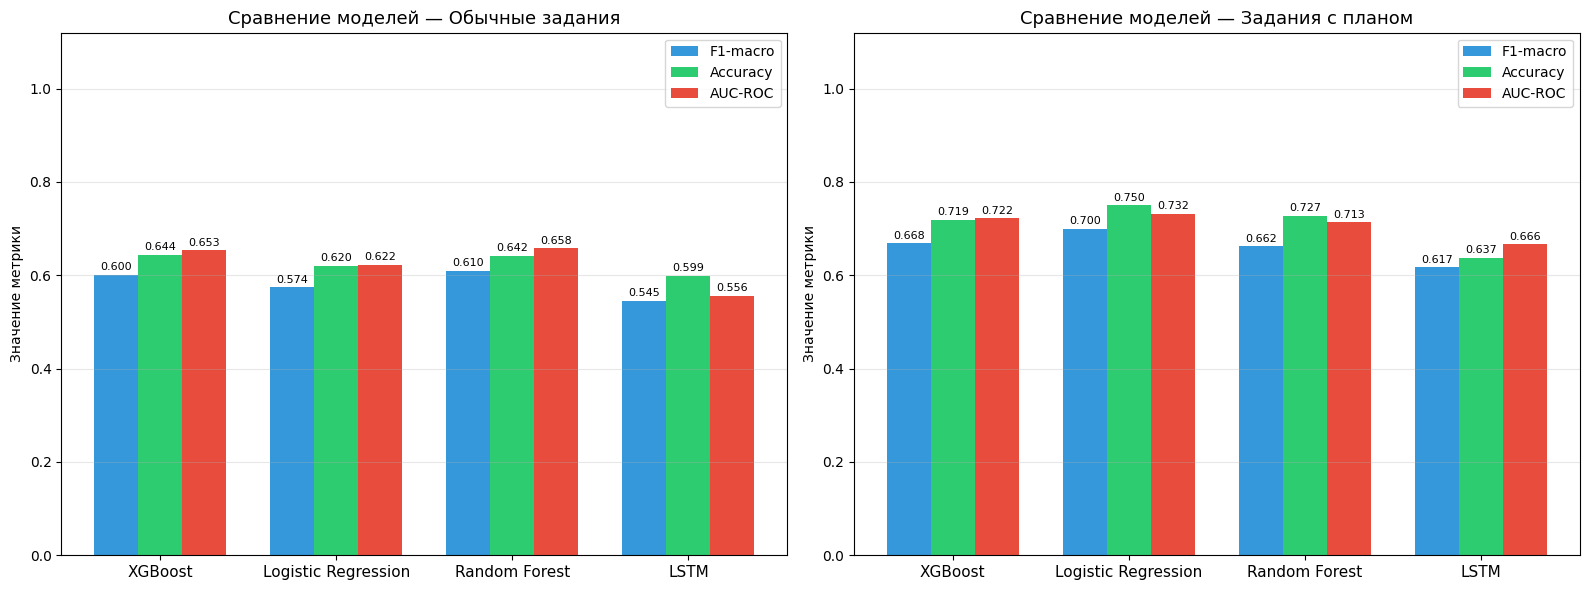

In [ ]:
models_names = ['XGBoost', 'Logistic Regression', 'Random Forest', 'LSTM']

# Обычные задания
y_pred_xgb_c  = (y_pred_proba_xgb  > best_thresh_xgb).astype(int)
y_pred_lr_c   = (y_pred_proba_lr   > best_thresh_lr).astype(int)
y_pred_rf_c   = (y_pred_proba_rf   > best_thresh_rf).astype(int)
y_pred_lstm_c = (y_pred_proba_lstm > best_thresh_lstm).astype(int)

f1_ord  = [f1_score(Y_test, p, average='macro') for p in [y_pred_xgb_c, y_pred_lr_c, y_pred_rf_c, y_pred_lstm_c]]
acc_ord = [accuracy_score(Y_test, p) for p in [y_pred_xgb_c, y_pred_lr_c, y_pred_rf_c, y_pred_lstm_c]]
auc_ord = [roc_auc_score(Y_test, p) for p in [y_pred_proba_xgb, y_pred_proba_lr, y_pred_proba_rf, y_pred_proba_lstm]]

# Задания с планом
y_pred_xgb_p       = (y_pred_proba_plan_xgb  > best_thresh_plan_xgb).astype(int)
y_pred_lr_p        = (y_pred_proba_plan_lr   > best_thresh_plan_lr).astype(int)
y_pred_rf_p        = (y_pred_proba_plan_rf   > best_thresh_plan_rf).astype(int)
y_pred_plan_lstm_c = (y_pred_proba_plan_lstm > best_thresh_plan_lstm).astype(int)

f1_plan  = [f1_score(Y_plan_test, p, average='macro') for p in [y_pred_xgb_p, y_pred_lr_p, y_pred_rf_p, y_pred_plan_lstm_c]]
acc_plan = [accuracy_score(Y_plan_test, p) for p in [y_pred_xgb_p, y_pred_lr_p, y_pred_rf_p, y_pred_plan_lstm_c]]
auc_plan = [roc_auc_score(Y_plan_test, p) for p in [y_pred_proba_plan_xgb, y_pred_proba_plan_lr, y_pred_proba_plan_rf, y_pred_proba_plan_lstm]]

#Графики
x = np.arange(len(models_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, f1s, accs, aucs, title in zip(axes, [f1_ord,  f1_plan], [acc_ord, acc_plan], [auc_ord, auc_plan], ['Обычные задания', 'Задания с планом']):
    b1 = ax.bar(x - width, f1s,  width, label='F1-macro', color='#3498db')
    b2 = ax.bar(x, accs, width, label='Accuracy', color='#2ecc71')
    b3 = ax.bar(x + width, aucs, width, label='AUC-ROC', color='#e74c3c')
    ax.set_xticks(x)
    ax.set_xticklabels(models_names, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(f'Сравнение моделей — {title}', fontsize=13)
    ax.set_ylabel('Значение метрики'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bars in [b1, b2, b3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# **Результаты и выводы**

Ниже представлены детальные метрики каждой модели: классификационный отчет, матрица ошибок, ROC-кривая и важность признаков

## Обычные задания

### XGBoost

In [ ]:
y_pred_xgb = (y_pred_proba_xgb > best_thresh_xgb).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_test, y_pred_xgb):.2%}")
print(classification_report(Y_test, y_pred_xgb))

Общая точность модели (Accuracy): 64.38%
              precision    recall  f1-score   support

           0       0.44      0.50      0.47      1458
           1       0.75      0.71      0.73      3140

    accuracy                           0.64      4598
   macro avg       0.60      0.60      0.60      4598
weighted avg       0.66      0.64      0.65      4598



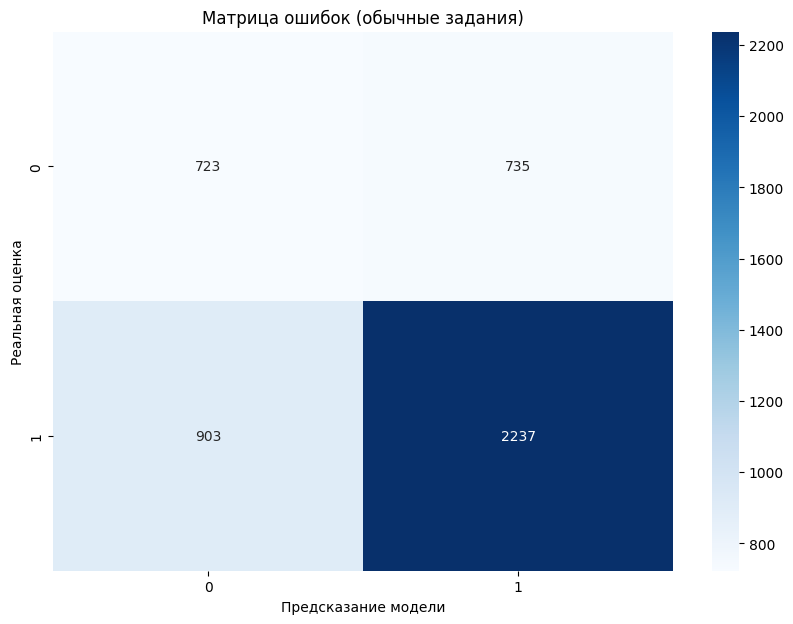

In [ ]:
cm = confusion_matrix(Y_test, y_pred_xgb) #Строим матрицу ошибок

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (обычные задания)')
plt.show()

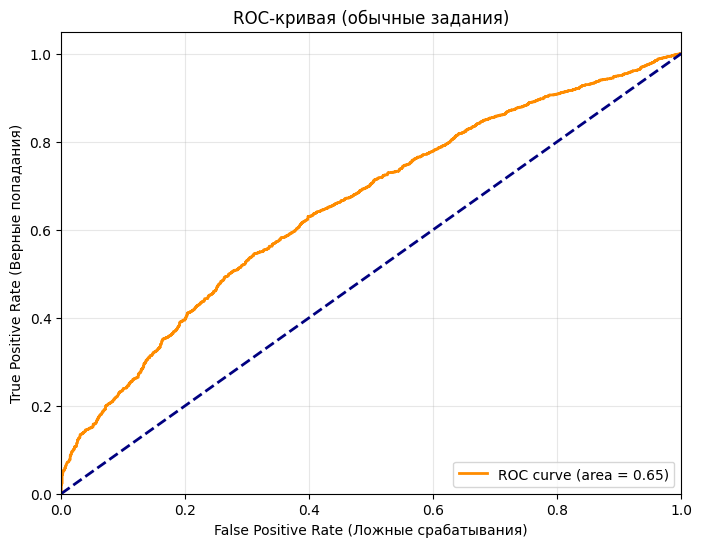

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba_xgb)
roc_auc = roc_auc_score(Y_test, y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (обычные задания)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

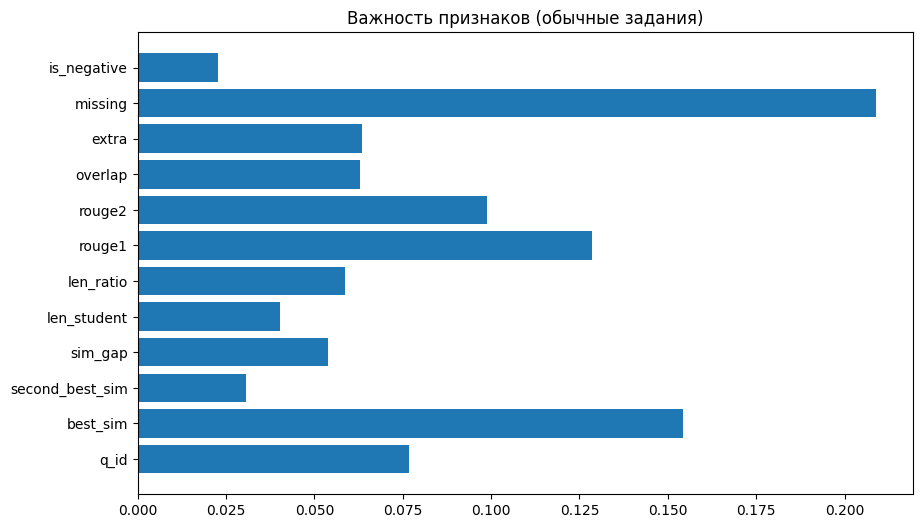

In [ ]:
#Отображаем на графике важность признаков
feature_names = ['q_id', 'best_sim', 'second_best_sim', 'sim_gap',
                 'len_student', 'len_ratio', 'rouge1', 'rouge2',
                 'overlap', 'extra', 'missing', 'is_negative']
feature_importance = model_xgb.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.title("Важность признаков (обычные задания)")
plt.show()

### LogisticRegression

In [ ]:
y_pred_lr = (y_pred_proba_lr > best_thresh_lr).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_test, y_pred_lr):.2%}")
print(classification_report(Y_test, y_pred_lr))

Общая точность модели (Accuracy): 61.96%
              precision    recall  f1-score   support

           0       0.41      0.46      0.43      1458
           1       0.73      0.69      0.71      3140

    accuracy                           0.62      4598
   macro avg       0.57      0.58      0.57      4598
weighted avg       0.63      0.62      0.62      4598



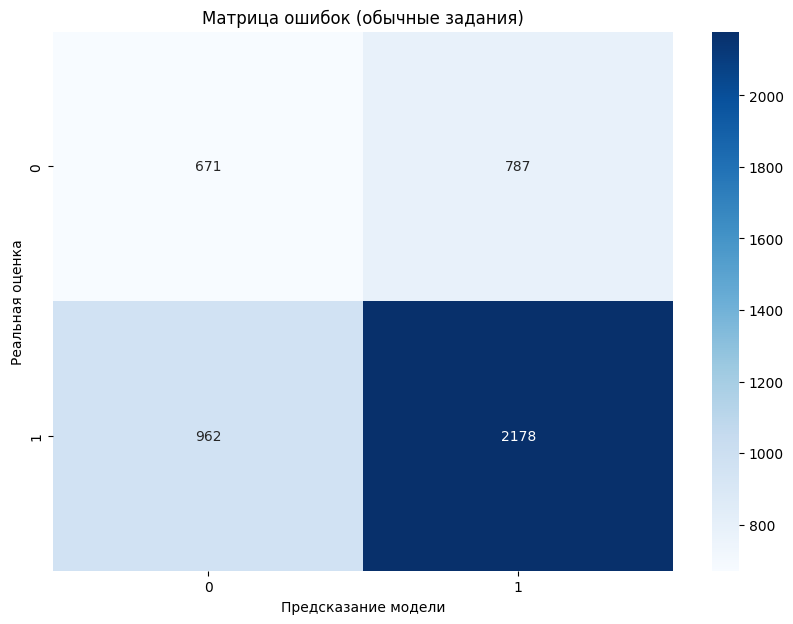

In [ ]:
cm = confusion_matrix(Y_test, y_pred_lr) #Строим матрицу ошибок

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (обычные задания)')
plt.show()

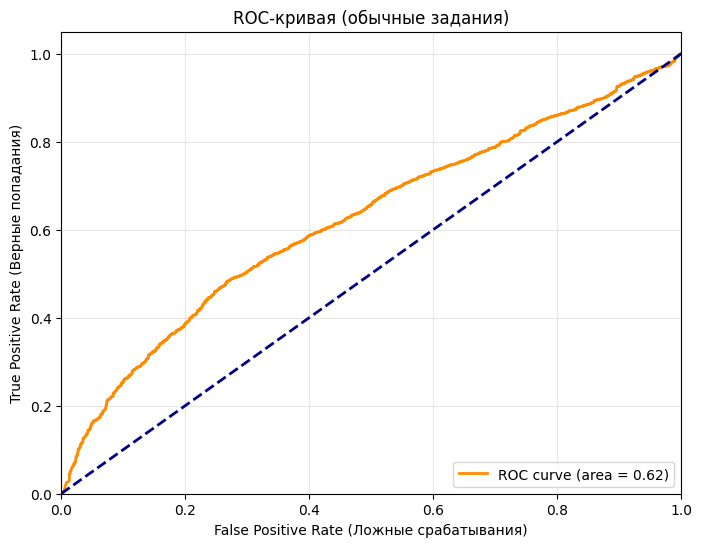

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba_lr)
roc_auc = roc_auc_score(Y_test, y_pred_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (обычные задания)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

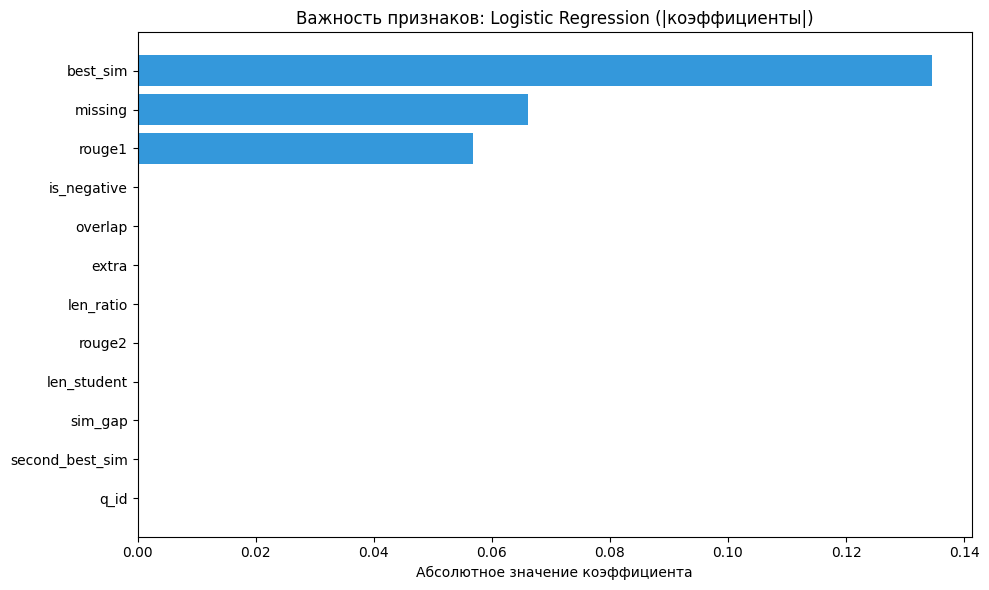

In [ ]:
#Отображаем на графике важность признаков
feature_names = ['q_id', 'best_sim', 'second_best_sim', 'sim_gap',
                 'len_student', 'len_ratio', 'rouge1', 'rouge2',
                 'overlap', 'extra', 'missing', 'is_negative']
feature_importance_lr = np.abs(model_lr.coef_[0])
sorted_idx = np.argsort(feature_importance_lr)
plt.figure(figsize=(10, 6))
plt.barh([feature_names[j] for j in sorted_idx], feature_importance_lr[sorted_idx], color='#3498db')
plt.title("Важность признаков: Logistic Regression (|коэффициенты|)")
plt.xlabel("Абсолютное значение коэффициента")
plt.tight_layout()
plt.show()

### RandomForest

In [ ]:
y_pred_rf = (y_pred_proba_rf > best_thresh_rf).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_test, y_pred_rf):.2%}")
print(classification_report(Y_test, y_pred_rf))

Общая точность модели (Accuracy): 64.22%
              precision    recall  f1-score   support

           0       0.45      0.56      0.50      1458
           1       0.77      0.68      0.72      3140

    accuracy                           0.64      4598
   macro avg       0.61      0.62      0.61      4598
weighted avg       0.67      0.64      0.65      4598



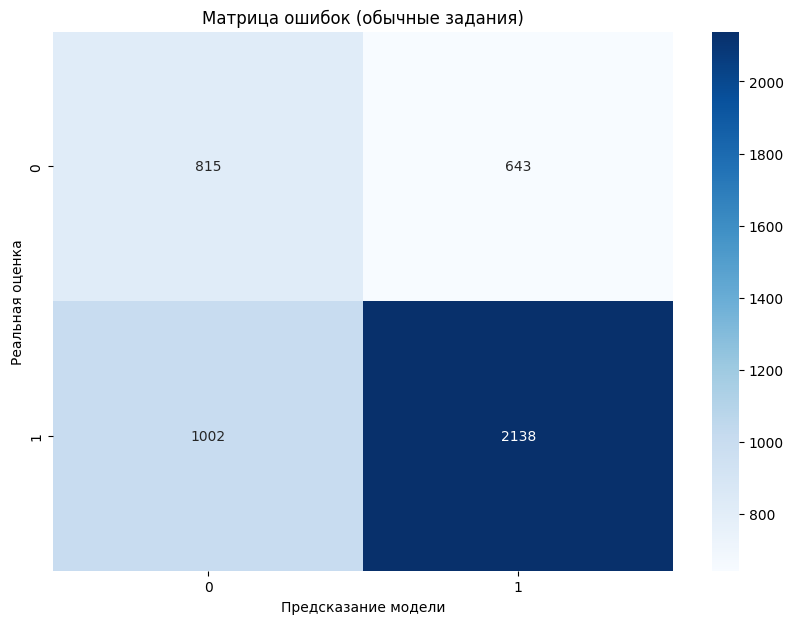

In [ ]:
cm = confusion_matrix(Y_test, y_pred_rf) #Строим матрицу ошибок

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (обычные задания)')
plt.show()

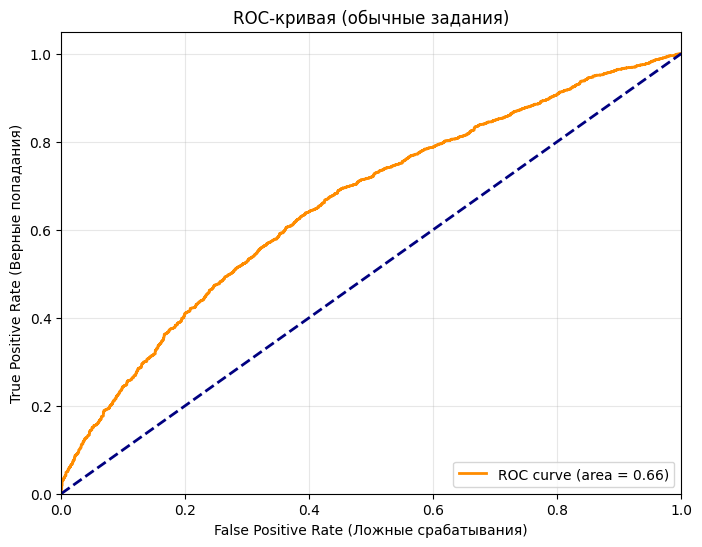

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba_rf)
roc_auc = roc_auc_score(Y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (обычные задания)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

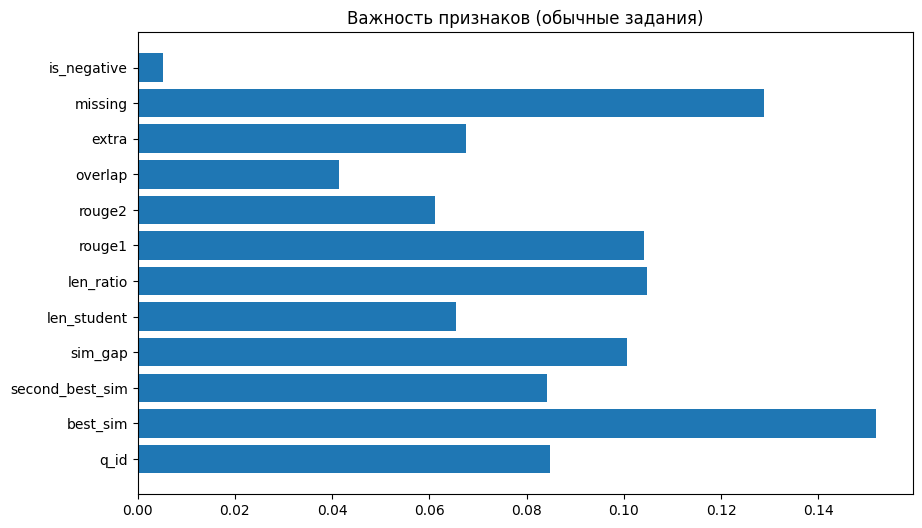

In [ ]:
#Отображаем на графике важность признаков
feature_names = ['q_id', 'best_sim', 'second_best_sim', 'sim_gap',
                 'len_student', 'len_ratio', 'rouge1', 'rouge2',
                 'overlap', 'extra', 'missing', 'is_negative']
feature_importance = model_rf.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.title("Важность признаков (обычные задания)")
plt.show()

### LSTM

In [ ]:
y_pred_lstm = (y_pred_proba_lstm >= best_thresh_lstm).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_test, y_pred_xgb):.2%}")
print(classification_report(Y_test, y_pred_lstm))

Общая точность модели (Accuracy): 64.38%
              precision    recall  f1-score   support

           0       0.38      0.40      0.39      1458
           1       0.71      0.69      0.70      3140

    accuracy                           0.60      4598
   macro avg       0.54      0.55      0.54      4598
weighted avg       0.61      0.60      0.60      4598



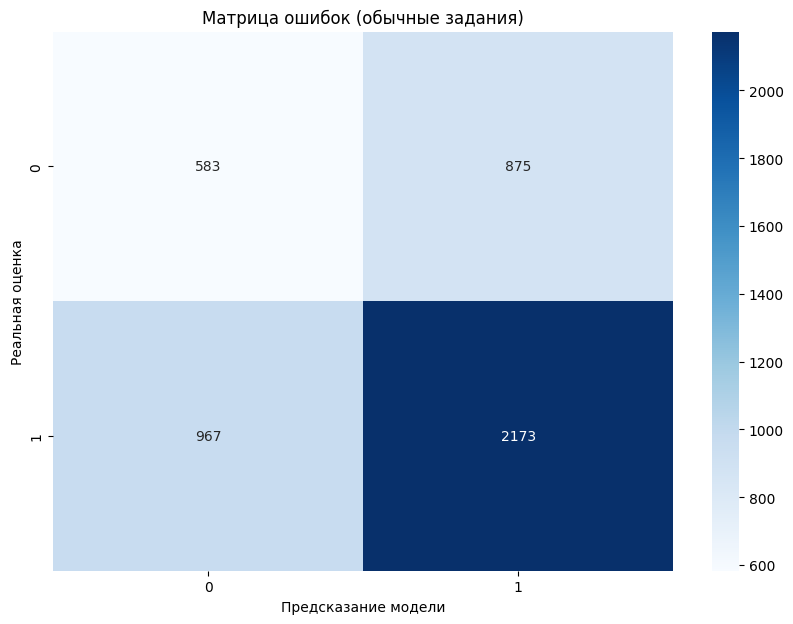

In [ ]:
cm = confusion_matrix(Y_test, y_pred_lstm) #Строим матрицу ошибок

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (обычные задания)')
plt.show()

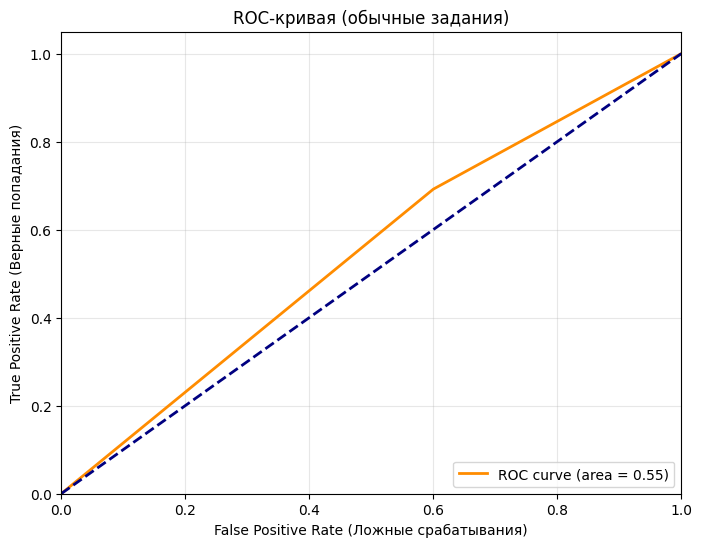

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_lstm)
roc_auc = roc_auc_score(Y_test, y_pred_lstm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (обычные задания)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Задания с планом

### XGBoost

In [ ]:
y_pred_plan_xgb = (y_pred_proba_plan_xgb > best_thresh_plan_xgb).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_plan_test, y_pred_plan_xgb):.2%}")
print(classification_report(Y_plan_test, y_pred_plan_xgb))

Общая точность модели (Accuracy): 71.93%
              precision    recall  f1-score   support

           0       0.58      0.50      0.54       159
           1       0.77      0.82      0.80       329

    accuracy                           0.72       488
   macro avg       0.68      0.66      0.67       488
weighted avg       0.71      0.72      0.71       488



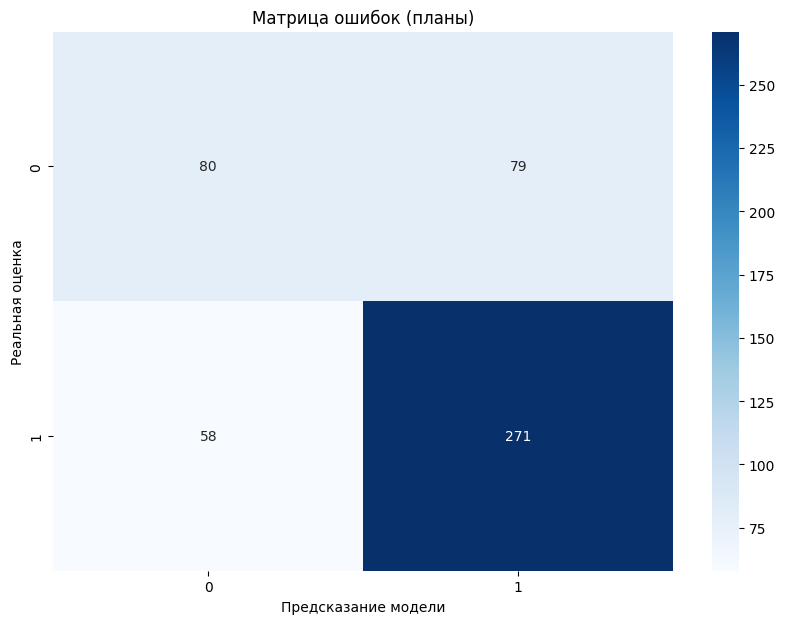

In [ ]:
cm_plan = confusion_matrix(Y_plan_test, y_pred_plan_xgb) #Строим матрицу

plt.figure(figsize=(10,7))
sns.heatmap(cm_plan, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (планы)')
plt.show()

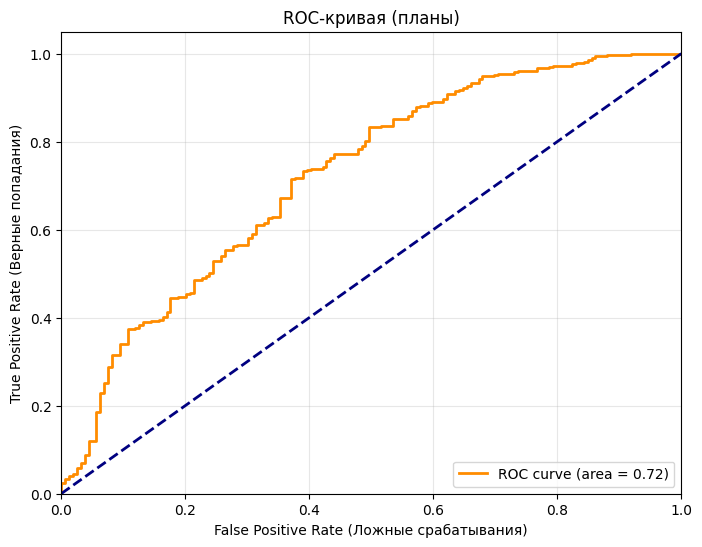

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_plan_test, y_pred_proba_plan_xgb)
roc_auc = roc_auc_score(Y_plan_test, y_pred_proba_plan_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (планы)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

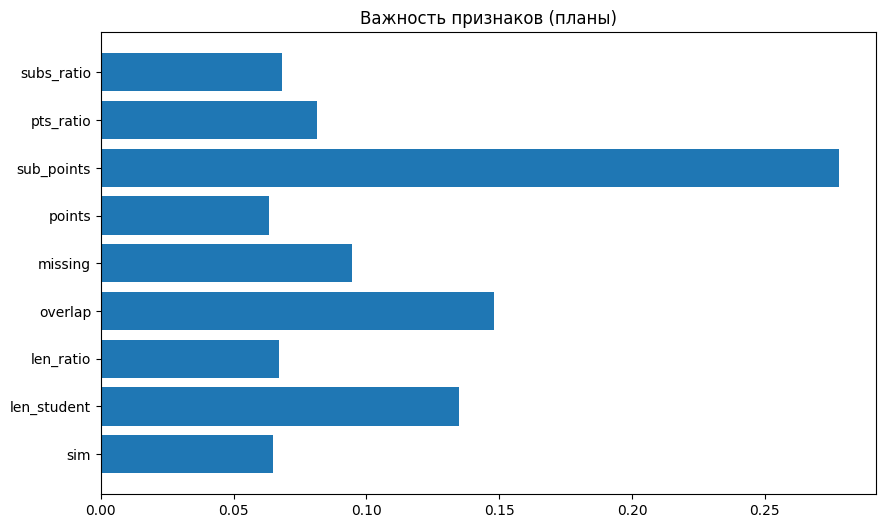

In [ ]:
#Отображаем на графике важность признаков
feature_names_plan = ['sim', 'len_student', 'len_ratio', 'overlap',
                 'missing', 'points', 'sub_points', 'pts_ratio',
                 'subs_ratio']
feature_importance_plan_xgb = model_plan_xgb.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names_plan, feature_importance_plan_xgb)
plt.title("Важность признаков (планы)")
plt.show()

### LogisticRegression

In [ ]:
y_pred_plan_lr = (y_pred_proba_plan_lr > best_thresh_plan_lr).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_plan_test, y_pred_plan_lr):.2%}")
print(classification_report(Y_plan_test, y_pred_plan_lr))

Общая точность модели (Accuracy): 75.00%
              precision    recall  f1-score   support

           0       0.64      0.52      0.58       159
           1       0.79      0.86      0.82       329

    accuracy                           0.75       488
   macro avg       0.72      0.69      0.70       488
weighted avg       0.74      0.75      0.74       488



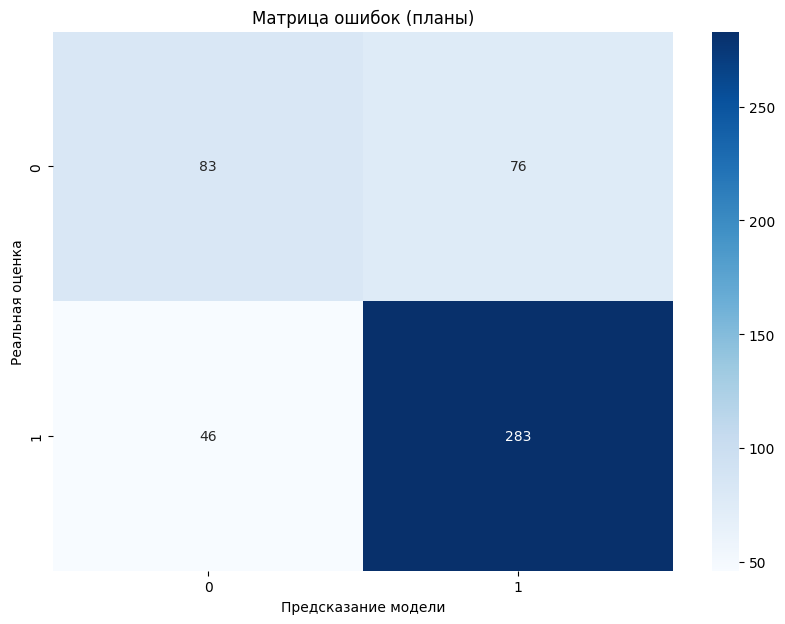

In [ ]:
cm_plan = confusion_matrix(Y_plan_test, y_pred_plan_lr) #Строим матрицу

plt.figure(figsize=(10,7))
sns.heatmap(cm_plan, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (планы)')
plt.show()

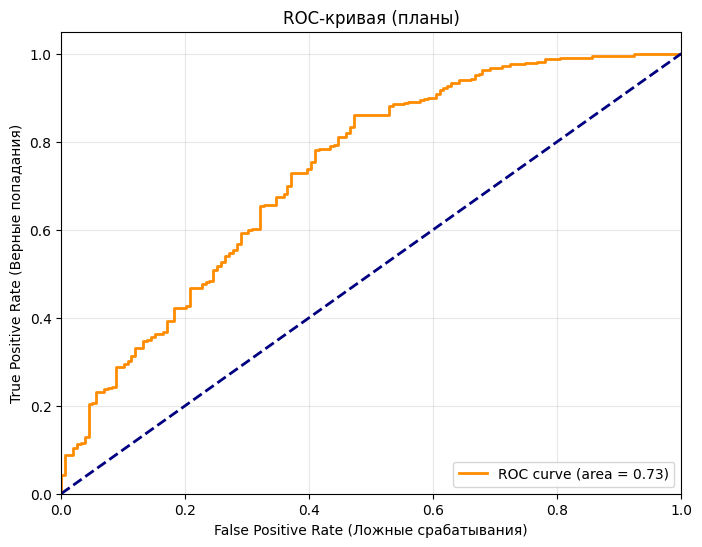

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_plan_test, y_pred_proba_plan_lr)
roc_auc = roc_auc_score(Y_plan_test, y_pred_proba_plan_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (планы)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

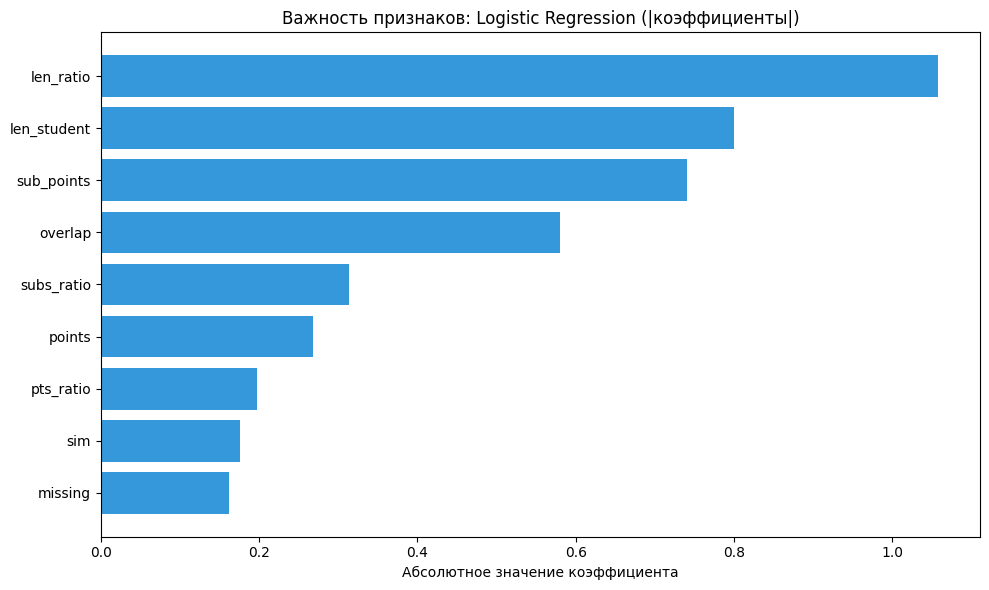

In [ ]:
#Отображаем на графике важность признаков
feature_names_plan = ['sim', 'len_student', 'len_ratio', 'overlap',
                 'missing', 'points', 'sub_points', 'pts_ratio',
                 'subs_ratio']
feature_importance_plan_lr = np.abs(model_plan_lr.coef_[0])
sorted_idx = np.argsort(feature_importance_plan_lr)
plt.figure(figsize=(10, 6))
plt.barh([feature_names_plan[j] for j in sorted_idx], feature_importance_plan_lr[sorted_idx], color='#3498db')
plt.title("Важность признаков: Logistic Regression (|коэффициенты|)")
plt.xlabel("Абсолютное значение коэффициента")
plt.tight_layout()
plt.show()

### RandomForest

In [ ]:
y_pred_plan_rf = (y_pred_proba_plan_rf > best_thresh_plan_rf).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_plan_test, y_pred_plan_rf):.2%}")
print(classification_report(Y_plan_test, y_pred_plan_rf))

Общая точность модели (Accuracy): 72.75%
              precision    recall  f1-score   support

           0       0.61      0.44      0.51       159
           1       0.76      0.87      0.81       329

    accuracy                           0.73       488
   macro avg       0.69      0.65      0.66       488
weighted avg       0.71      0.73      0.71       488



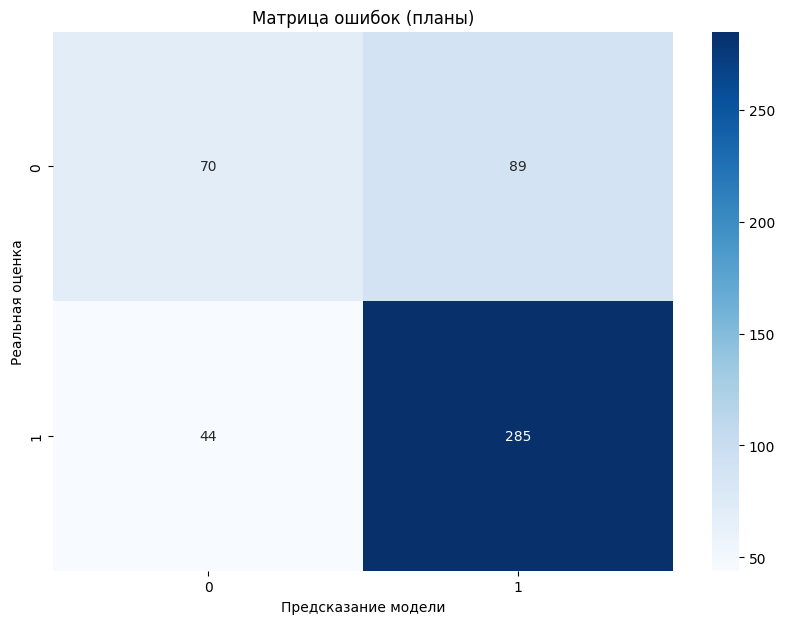

In [ ]:
cm_plan = confusion_matrix(Y_plan_test, y_pred_plan_rf) #Строим матрицу

plt.figure(figsize=(10,7))
sns.heatmap(cm_plan, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (планы)')
plt.show()

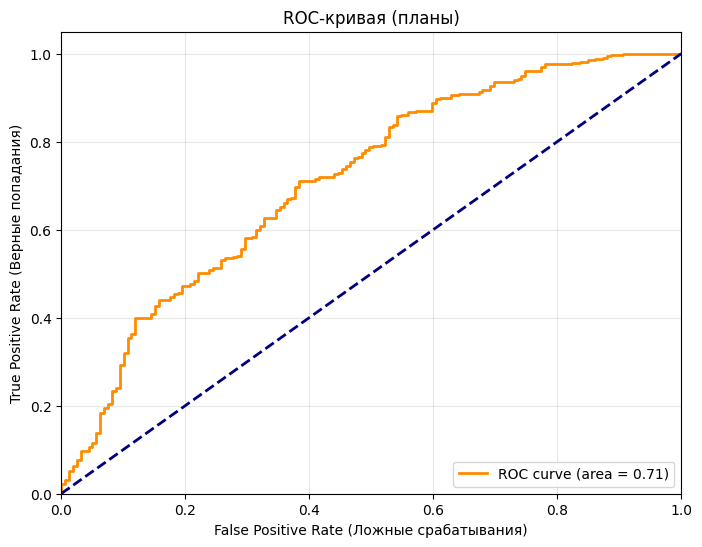

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_plan_test, y_pred_proba_plan_rf)
roc_auc = roc_auc_score(Y_plan_test, y_pred_proba_plan_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (планы)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

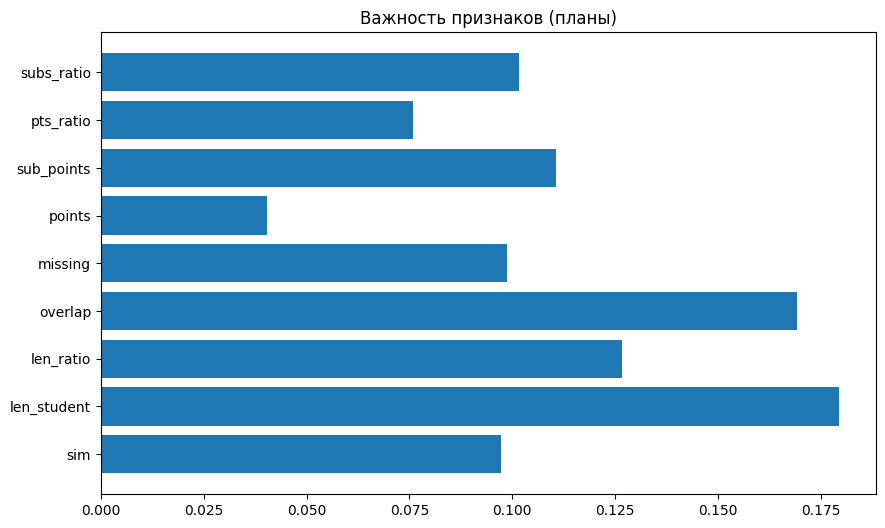

In [ ]:
#Отображаем на графике важность признаков
feature_names_plan = ['sim', 'len_student', 'len_ratio', 'overlap',
                 'missing', 'points', 'sub_points', 'pts_ratio',
                 'subs_ratio']
feature_importance_plan_rf = model_plan_rf.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names_plan, feature_importance_plan_rf)
plt.title("Важность признаков (планы)")
plt.show()

### LSTM

In [ ]:
y_pred_plan_lstm = (y_pred_proba_plan_lstm >= best_thresh_plan_lstm).astype(int) #Применяем найденный порог

print(f"Общая точность модели (Accuracy): {accuracy_score(Y_plan_test, y_pred_plan_lstm):.2%}")
print(classification_report(Y_plan_test, y_pred_plan_lstm))

Общая точность модели (Accuracy): 63.73%
              precision    recall  f1-score   support

           0       0.46      0.62      0.53       159
           1       0.78      0.64      0.71       329

    accuracy                           0.64       488
   macro avg       0.62      0.63      0.62       488
weighted avg       0.67      0.64      0.65       488



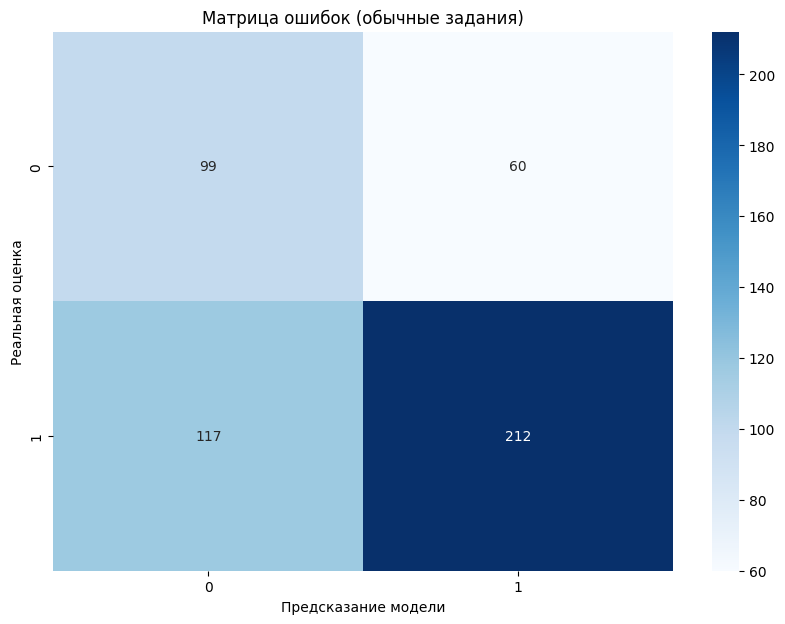

In [ ]:
cm = confusion_matrix(Y_plan_test, y_pred_plan_lstm) #Строим матрицу ошибок

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальная оценка')
plt.title('Матрица ошибок (обычные задания)')
plt.show()

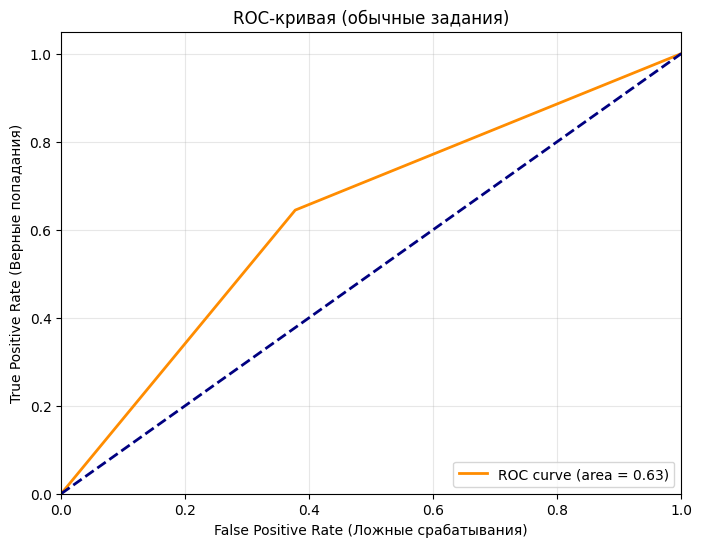

In [ ]:
#Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(Y_plan_test, y_pred_plan_lstm)
roc_auc = roc_auc_score(Y_plan_test, y_pred_plan_lstm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Верные попадания)')
plt.title('ROC-кривая (обычные задания)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Заключение**

## Итоги проекта

В рамках проекта была решена задача автоматической проверки ответов учеников на вопросы по обществознанию. Решение построено на основе методов машинного обучения и обработки естественного языка

### Что было сделано:

1. **Сбор и парсинг данных** Разработан парсер для извлечения ответов учеников и оценок учителей из размеченного датасета `querc.json`. Отдельно обработаны обычные задания и задания с планом

2. **Анализ данных** Исследовано распределение классов, длины ответов и статистика по типам заданий. Датасет имеет умеренный дисбаланс классов, что учтено при обучении через параметр `class_weight`

3. **Векторизация** Ответы преобразованы в числовые признаки с использованием нейросетевой модели SentenceTransformer (`paraphrase-multilingual-mpnet-base-v2`), а также метрик ROUGE, лексического перекрытия и статистических характеристик текста

4. **Обучение моделей** Обучены три алгоритма машинного обучения:
   - **XGBoost** — ансамблевый метод градиентного бустинга;
   - **Random Forest** — ансамблевый метод на основе деревьев решений;
   - **Logistic Regression** — линейный классификатор (обучается на масштабированных признаках)

   Для каждой модели подобраны гиперпараметры через кросс-валидацию и оптимизирован порог классификации по метрике F1-macro

5. **Нейронная сеть** В качестве нейросетевого компонента в обучении использована рекуррентная сеть на основе архитектуры LSTM (Long Short-Term Memory). В отличие от обычных нейросетей, LSTM читает данные последовательно и сохраняет память о предыдущих шагах, что позволяет учитывать контекст

### Выводы:

Результаты моделей различаются в зависимости от типа задания.

На **обычных заданиях** наилучший результат показал **Random Forest** (F1-macro = 0.61), незначительно опередив XGBoost (0.60). Logistic Regression уступает обоим (0.57) — вероятно, из-за нелинейных зависимостей в признаковом пространстве при большом объёме данных. Разница между Random Forest и XGBoost минимальна и находится в пределах статистической погрешности. LSTM показал результат F1-macro = 0.54, что уступило ансамблевым методам — это ожидаемо, поскольку модель не использует вручную подобранные признаки и вынуждена извлекать зависимости из сырых эмбеддингов, что требует значительно больше данных

На **заданиях с планом** картина иная: лучший результат показала **Logistic Regression** (F1-macro = 0.70, Accuracy = 75.0%), опередив XGBoost (0.67) и Random Forest (0.66). Это объясняется небольшим объёмом данных по планам — в таких условиях простая линейная модель обобщается лучше сложных ансамблей. LSTM на заданиях с планом показал F1-macro = 0.65, что сопоставимо с результатами ансамблевых методов. Это говорит о том, что даже на малом объёме данных нейросеть способна конкурировать с классическими методами на заданиях с планом

Сравнение всех четырёх моделей показывает, что классические алгоритмы машинного обучения на вручную подобранных признаках в данной задаче превосходят LSTM. Это объясняется тем, что признаки (косинусное сходство, ROUGE, лексическое перекрытие) уже хорошо описывают суть задачи — насколько ответ ученика близок к эталону. LSTM, получая только сырые эмбеддинги, вынужден заново учиться этому сравнению на ограниченном датасете. При значительном расширении данных нейросетевой подход мог бы показать конкурентные результаты

В целом полученные результаты показывают, что автоматическая оценка коротких текстовых ответов является решаемой задачей при наличии эталонных ответов. Ключевым признаком во всех моделях оказалось семантическое сходство ответа ученика с эталоном, для вычисления которого тексты предварительно преобразовывались в векторные представления с помощью нейросетевой модели SentenceTransformer. Это подтверждает важность контекстного понимания текста в задачах автоматической проверки. Дальнейшее улучшение качества возможно за счёт расширения датасета, особенно для заданий с планом, где объём данных существенно ограничен